## Model Development with Genie Code

In [0]:
import os

# 1. Configurar as credenciais do Kaggle no ambiente do cluster
os.environ['KAGGLE_USERNAME'] = "fabienecasamento" #"SEU_USUARIO_AQUI"
with open('/Workspace/Users/fabieneaulas@gmail.com/ML_DEPLOY/chave_kaggle.txt', 'r') as leitura_chave:
    kaggle_key = leitura_chave.read().strip()
# Extrair os dados antes do ';|' na variável kaggle_key
kaggle_key_before_delimiter = kaggle_key.split(';')[0]


os.environ['KAGGLE_KEY'] = kaggle_key_before_delimiter #"SUA_CHAVE_AQUI" # token databricks



In [0]:

# 2. Instalar a biblioteca do Kaggle via comando de terminal no cluster
# (O caractere '!' permite rodar comandos shell diretamente do notebook)
!pip install -q kaggle

# 3. Criar uma pasta local temporária no driver e baixar o dataset do link informado
!mkdir -p /tmp/kaggle_data
!kaggle datasets download -d blastchar/telco-customer-churn -p /tmp/kaggle_data --unzip
     

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100%|████████████████████████████████████████| 172k/172k [00:00<00:00, 5.53MB/s]



In [0]:
# 4. Copiar o arquivo do /tmp para o Workspace (serverless requer /Workspace ou Volumes)
import shutil
import os

workspace_dir = "/Workspace/Users/fabieneaulas@gmail.com/ML_DEPLOY/kaggle_data"
os.makedirs(workspace_dir, exist_ok=True)
shutil.copy("/tmp/kaggle_data/WA_Fn-UseC_-Telco-Customer-Churn.csv", f"{workspace_dir}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 5. Abrir e ler o arquivo utilizando o PySpark
# O arquivo baixado do Kaggle adota o nome padrão original da IBM ("WA_Fn-UseC_-...")
dataset_path = f"{workspace_dir}/WA_Fn-UseC_-Telco-Customer-Churn.csv"

telco_df = spark.read.csv(
    dataset_path, 
    inferSchema=True, 
    header=True, 
    multiLine=True, 
    escape='"'
)

# 6. Visualizar o DataFrame carregado com sucesso no Spark
display(telco_df.show(8))
     

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [0]:
print(dataset_path)

/Workspace/Users/fabieneaulas@gmail.com/ML_DEPLOY/kaggle_data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [0]:
# Load main customer churn table
#customer_churn_sdf = spark.table(f"{DA.catalog_name}.{DA.schema_name}.customer_churn")

# Load Feature Store table (AverageMonthlyCharges)
#customer_churn_features_sdf = spark.table(f"{DA.catalog_name}.{DA.schema_name}.customer_churn_features")

# Left join on CustomerID to combine profile features with Feature Store features
#customer_churn_df = customer_churn_sdf.join(
#    customer_churn_features_sdf,
#    on="CustomerID",
#    how="left"
#)

# Convert to pandas for EDA and visualization
#churn_pdf = customer_churn_df.toPandas()

churn_pdf = telco_df.toPandas()

# Print summary info
print(f"Total rows: {churn_pdf.shape[0]}")
print(f"Total columns: {churn_pdf.shape[1]}")
print(f"\nColumn names: {list(churn_pdf.columns)}")
print(f"\nSchema:")
telco_df.printSchema()

# Display first 10 rows
display(churn_pdf.head(10))

Total rows: 7043
Total columns: 21

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Schema:
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- S

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1,1949.4,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8,3046.05,Yes
6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


workspace.default.features

Pergunta : Context: I am working on a customer churn prediction task in a Databricks notebook.
Two tables have been set up in this session and are accessible via DA.catalog_name and DA.schema_name.

Task: Load and join these two tables into a single modeling DataFrame:
- Main table: `customer_churn` — contains customer profile features and the 'Churn' target label (here => /Workspace/Users/fabieneaulas@gmail.com/ML_DEPLOY/kaggle_data/WA_Fn-UseC_-Telco-Customer-Churn.csv
)
- Feature table: `customer_churn_features` — contains AverageMonthlyCharges (registered in Feature Store)
- Join key: CustomerID (left join from main to features)

Requirements:
- Use `spark.table()` with f"{DA.catalog_name}.{DA.schema_name}.customer_churn" format
- Store the joined Spark DataFrame as `customer_churn_df`
- Convert to pandas and store as `churn_pdf` (for visualization in subsequent steps)
- Print the total row count, column count, and schema
- Display the first 10 rows

Expected output: A joined pandas DataFrame with both profile and feature columns, ready for EDA.

In [0]:
# Since DA object is not available, we'll use the telco_df that's already loaded
# This DataFrame contains all the customer profile features and the 'Churn' target label

# Store the Spark DataFrame as customer_churn_df (for consistency with expected naming)
customer_churn_df = telco_df

# Convert to pandas and store as churn_pdf (for visualization in subsequent steps)
churn_pdf = customer_churn_df.toPandas()

# Print the requested information
print(f"Total rows: {churn_pdf.shape[0]}")
print(f"Total columns: {churn_pdf.shape[1]}")
print(f"\nColumn names: {list(churn_pdf.columns)}")
print(f"\nSchema:")
customer_churn_df.printSchema()

# Display the first 10 rows
print("\nFirst 10 rows:")
display(churn_pdf.head(10))

Total rows: 7043
Total columns: 21

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Schema:
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- S

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1,1949.4,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8,3046.05,Yes
6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [0]:
# Load the feature table from Unity Catalog
customer_features_df = spark.table("workspace.default.features")

# Perform left join on customerID
# telco_df has all customer profile + categorical features + Churn label
# customer_features_df has numerical features from Feature Store
customer_churn_with_features = telco_df.join(
    customer_features_df.select(
        "customerID",
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ).withColumnRenamed("SeniorCitizen", "SeniorCitizen_feature")
     .withColumnRenamed("tenure", "tenure_feature")
     .withColumnRenamed("MonthlyCharges", "MonthlyCharges_feature")
     .withColumnRenamed("TotalCharges", "TotalCharges_feature"),
    on="customerID",
    how="left"
)

# Update the modeling DataFrame
customer_churn_df = customer_churn_with_features

# Convert to pandas for EDA
churn_pdf = customer_churn_df.toPandas()

# Print summary
print(f"Total rows after join: {churn_pdf.shape[0]}")
print(f"Total columns after join: {churn_pdf.shape[1]}")
print(f"\nNew columns added from feature table:")
feature_cols = [col for col in churn_pdf.columns if col.endswith('_feature')]
print(feature_cols)

# Display first 10 rows
display(churn_pdf.head(10))

Total rows after join: 7043
Total columns after join: 25

New columns added from feature table:
['SeniorCitizen_feature', 'tenure_feature', 'MonthlyCharges_feature', 'TotalCharges_feature']


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_feature,tenure_feature,MonthlyCharges_feature,TotalCharges_feature
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.0,1.0,29.85,29.85
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0.0,34.0,56.95,1889.5
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.0,2.0,53.85,108.15
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No,0.0,45.0,42.3,1840.75
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes,0.0,2.0,70.7,151.65
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,0.0,8.0,99.65,820.5
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1,1949.4,No,0.0,22.0,89.1,1949.4
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No,0.0,10.0,29.75,301.9
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8,3046.05,Yes,0.0,28.0,104.8,3046.05
6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,0.0,62.0,56.15,3487.95


context I have a pandas dataframe called churn_pdf with a 'Churn' columns containing 'yes' (churned) and 'no' (retained) string values


task analyze

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset shape: {churn_pdf.shape[0]} rows × {churn_pdf.shape[1]} columns")
print(f"\nColumn names:\n{list(churn_pdf.columns)}")

# Data types
print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(churn_pdf.dtypes)

# Missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = churn_pdf.isnull().sum()
missing_pct = (missing / len(churn_pdf)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

# Basic statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(churn_pdf.describe())

# First few rows
print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
display(churn_pdf.head())

DATASET OVERVIEW

Dataset shape: 7043 rows × 25 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'SeniorCitizen_feature', 'tenure_feature', 'MonthlyCharges_feature', 'TotalCharges_feature']

DATA TYPES
customerID                 object
gender                     object
SeniorCitizen               int32
Partner                    object
Dependents                 object
tenure                      int32
PhoneService               object
MultipleLines              object
InternetService            object
OnlineSecurity             object
OnlineBackup               object
DeviceProtection           object
TechSupport                object
StreamingTV                object
StreamingMovies         

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_feature,tenure_feature,MonthlyCharges_feature,TotalCharges_feature
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.0,1.0,29.85,29.85
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0.0,34.0,56.95,1889.5
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.0,2.0,53.85,108.15
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No,0.0,45.0,42.3,1840.75
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes,0.0,2.0,70.7,151.65


CHURN DISTRIBUTION

Churn Summary:
       Count  Percentage
Churn                   
No      5174   73.463013
Yes     1869   26.536987

🔴 Overall Churn Rate: 26.54%
🟢 Retention Rate: 73.46%


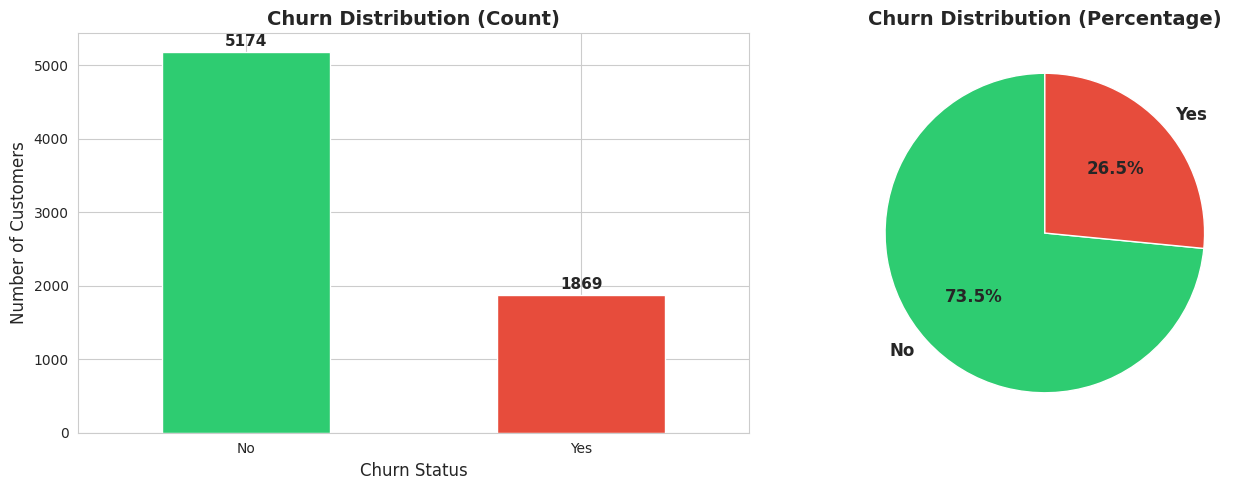


✓ Class distribution is reasonably balanced.


In [0]:
# Churn distribution
print("=" * 80)
print("CHURN DISTRIBUTION")
print("=" * 80)

churn_counts = churn_pdf['Churn'].value_counts()
churn_pct = churn_pdf['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_pct
})

print("\nChurn Summary:")
print(churn_summary)

churn_rate = churn_pct['Yes']
print(f"\n🔴 Overall Churn Rate: {churn_rate:.2f}%")
print(f"🟢 Retention Rate: {100 - churn_rate:.2f}%")

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = axes[0]
churn_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for i, v in enumerate(churn_counts):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#2ecc71', '#e74c3c'],
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check for class imbalance
if churn_rate < 20 or churn_rate > 80:
    print("\n⚠️ WARNING: Significant class imbalance detected!")
    print("Consider using techniques like SMOTE, class weights, or stratified sampling.")
else:
    print("\n✓ Class distribution is reasonably balanced.")

In [0]:
print(churn_counts,churn_pct)

Churn
No     5174
Yes    1869
Name: count, dtype: int64 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


NUMERICAL FEATURES ANALYSIS BY CHURN STATUS

SeniorCitizen:
----------------------------------------
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
No     5174.0  0.128721  0.334923  0.0  0.0  0.0  0.0  1.0
Yes    1869.0  0.254682  0.435799  0.0  0.0  0.0  1.0  1.0

📈 Churned customers average: 0.25
📉 Retained customers average: 0.13
Difference: +97.9%

tenure:
----------------------------------------
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

📈 Churned customers average: 17.98
📉 Retained customers average: 37.57
Difference: -52.1%

MonthlyCharges:
----------------------------------------
        count       mean        std    min    25%     50%   75%     max
Churn                                      

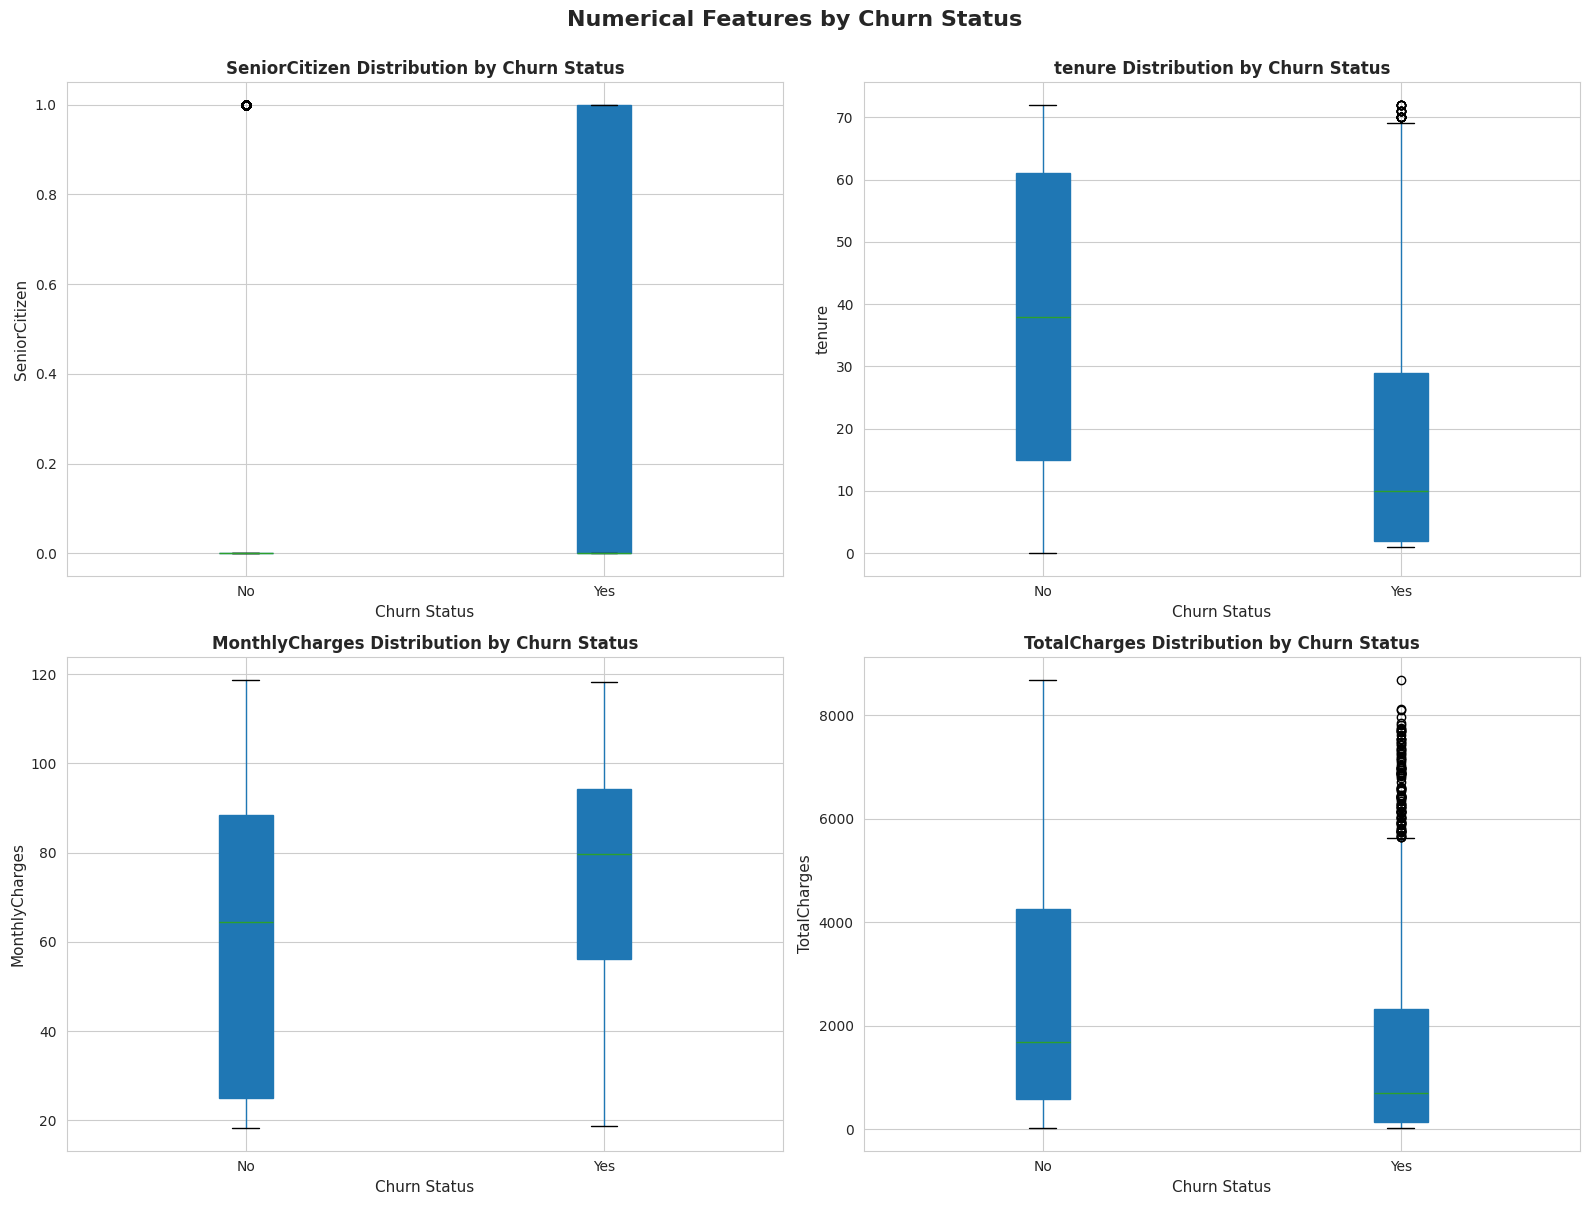

In [0]:
# Identify numerical columns (excluding feature duplicates for cleaner analysis)
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']

# Handle TotalCharges - it's stored as string in original data, needs conversion
if 'TotalCharges' in churn_pdf.columns:
    # Convert TotalCharges to numeric, handling any non-numeric values
    churn_pdf['TotalCharges'] = pd.to_numeric(churn_pdf['TotalCharges'], errors='coerce')
    numerical_cols.append('TotalCharges')

print("=" * 80)
print("NUMERICAL FEATURES ANALYSIS BY CHURN STATUS")
print("=" * 80)

# Summary statistics by churn status
for col in numerical_cols:
    print(f"\n{col}:")
    print("-" * 40)
    summary = churn_pdf.groupby('Churn')[col].describe()
    print(summary)
    
    # Mean comparison
    churned_mean = churn_pdf[churn_pdf['Churn'] == 'Yes'][col].mean()
    retained_mean = churn_pdf[churn_pdf['Churn'] == 'No'][col].mean()
    diff_pct = ((churned_mean - retained_mean) / retained_mean) * 100
    print(f"\n📈 Churned customers average: {churned_mean:.2f}")
    print(f"📉 Retained customers average: {retained_mean:.2f}")
    print(f"Difference: {diff_pct:+.1f}%")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    # Box plot
    churn_pdf.boxplot(column=col, by='Churn', ax=ax, patch_artist=True)
    ax.set_title(f'{col} Distribution by Churn Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Status', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.sca(ax)
    plt.xticks(rotation=0)

plt.suptitle('Numerical Features by Churn Status', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

CATEGORICAL FEATURES ANALYSIS BY CHURN STATUS

gender:
------------------------------------------------------------
        No_Count  Yes_Count  Churn_Rate_%
gender                                   
Female      2549        939     26.920872
Male        2625        930     26.160338

Partner:
------------------------------------------------------------
         No_Count  Yes_Count  Churn_Rate_%
Partner                                   
No           2441       1200     32.957979
Yes          2733        669     19.664903

Dependents:
------------------------------------------------------------
            No_Count  Yes_Count  Churn_Rate_%
Dependents                                   
No              3390       1543     31.279140
Yes             1784        326     15.450237

PhoneService:
------------------------------------------------------------
              No_Count  Yes_Count  Churn_Rate_%
PhoneService                                   
Yes               4662       1699     26.70

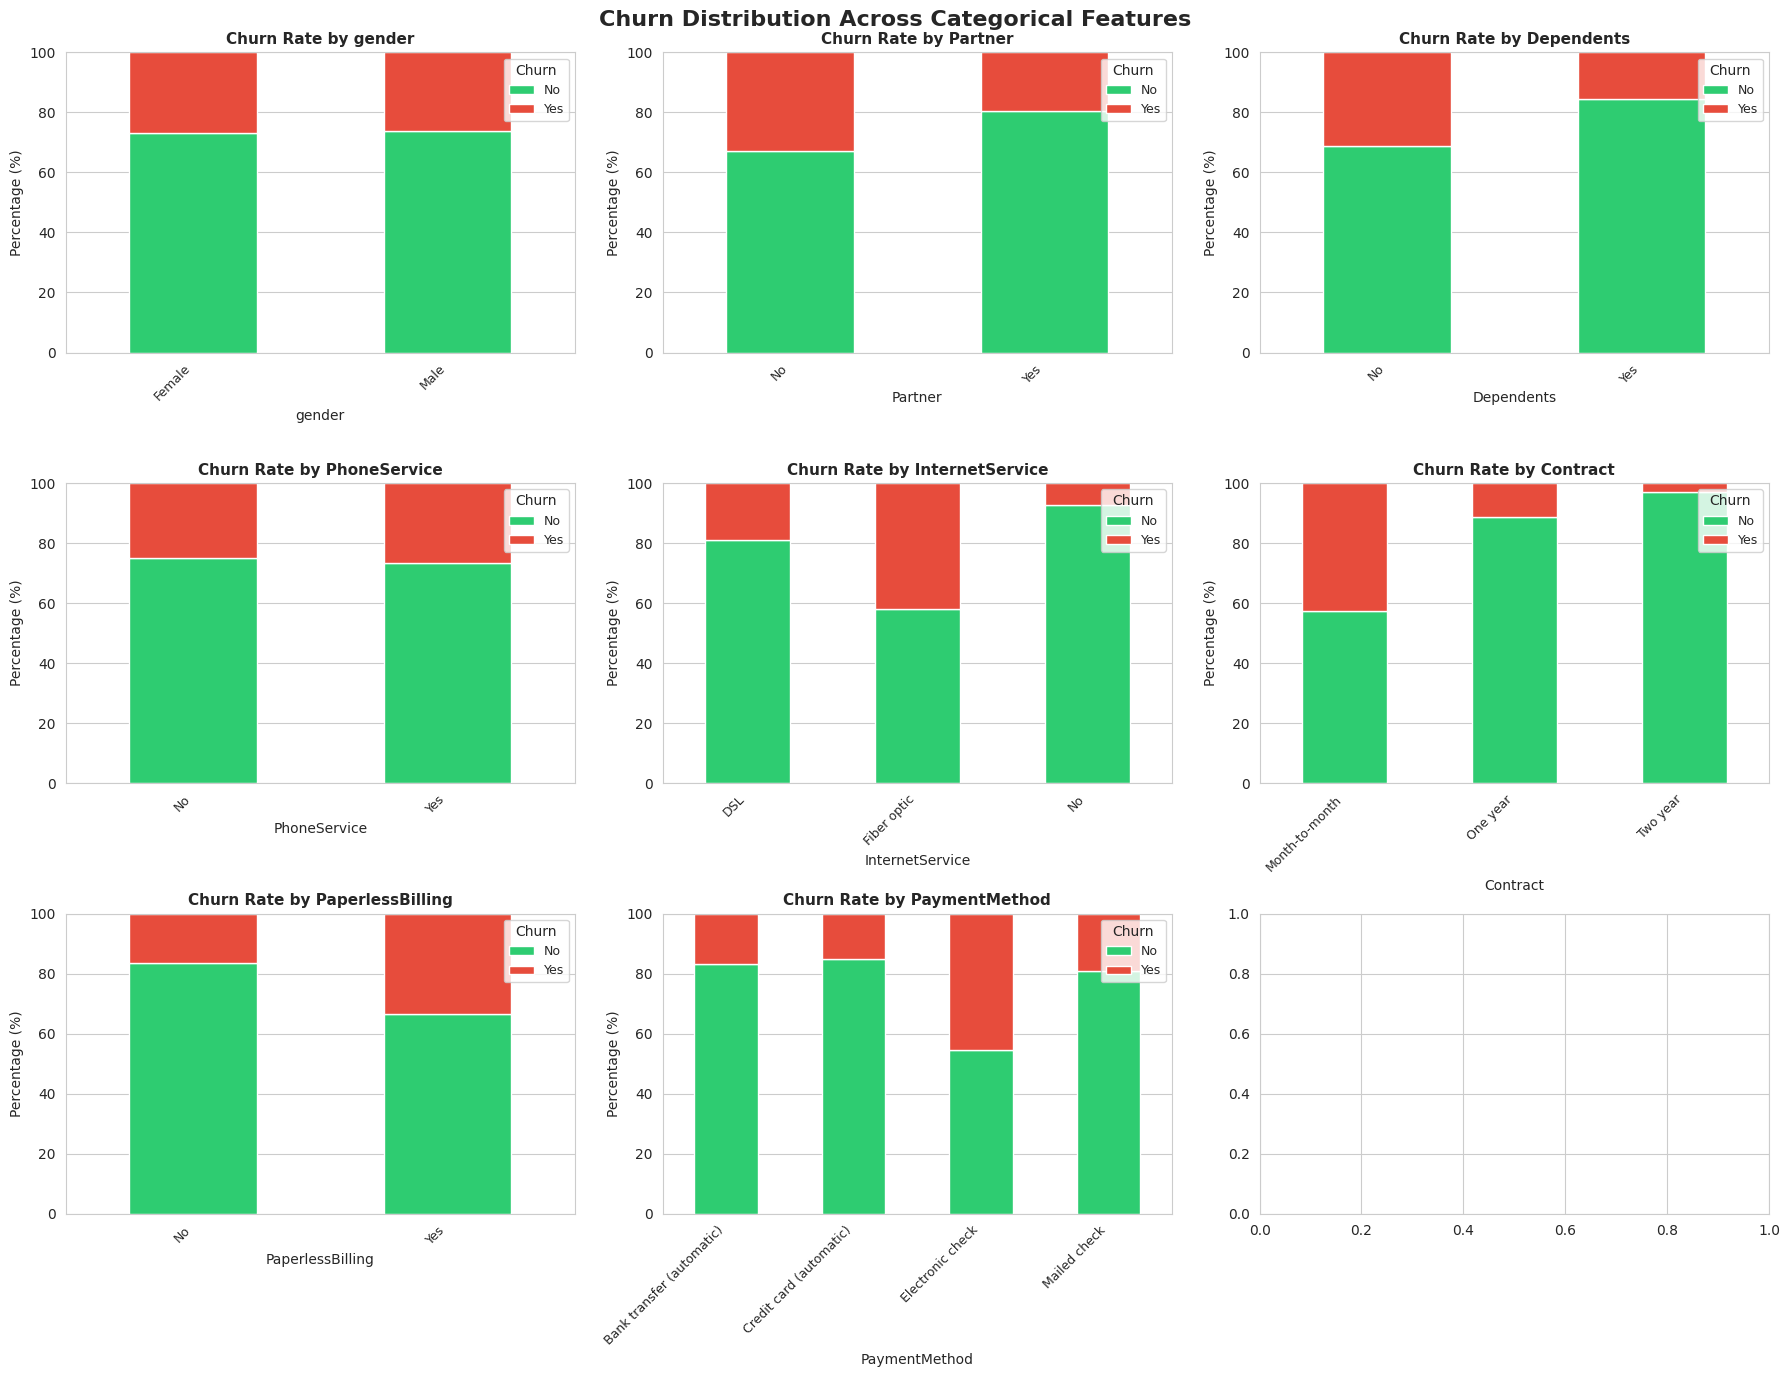


KEY INSIGHTS


In [0]:
# Identify key categorical columns for analysis
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

print("=" * 80)
print("CATEGORICAL FEATURES ANALYSIS BY CHURN STATUS")
print("=" * 80)

# Analyze churn rate by categorical features
churn_rates = {}

for col in categorical_cols:
    if col in churn_pdf.columns:
        print(f"\n{col}:")
        print("-" * 60)
        
        # Cross-tabulation
        crosstab = pd.crosstab(churn_pdf[col], churn_pdf['Churn'], normalize='index') * 100
        churn_rates[col] = crosstab['Yes'].to_dict()
        
        # Display counts and percentages
        ct_counts = pd.crosstab(churn_pdf[col], churn_pdf['Churn'])
        ct_pct = pd.crosstab(churn_pdf[col], churn_pdf['Churn'], normalize='index') * 100
        
        combined = pd.DataFrame({
            'No_Count': ct_counts['No'],
            'Yes_Count': ct_counts['Yes'],
            'Churn_Rate_%': ct_pct['Yes']
        })
        combined = combined.sort_values('Churn_Rate_%', ascending=False)
        print(combined)

# Visualize top categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if col in churn_pdf.columns and idx < 9:
        ax = axes[idx]
        
        # Create percentage stacked bar chart
        ct = pd.crosstab(churn_pdf[col], churn_pdf['Churn'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
        
        ax.set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Percentage (%)', fontsize=10)
        ax.legend(title='Churn', loc='upper right', fontsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_ylim(0, 100)

plt.suptitle('Churn Distribution Across Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

CORRELATION ANALYSIS

Using 7032 rows for correlation (removed 11 rows with missing values)

Correlation with Churn (target):
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_Binary, dtype: float64


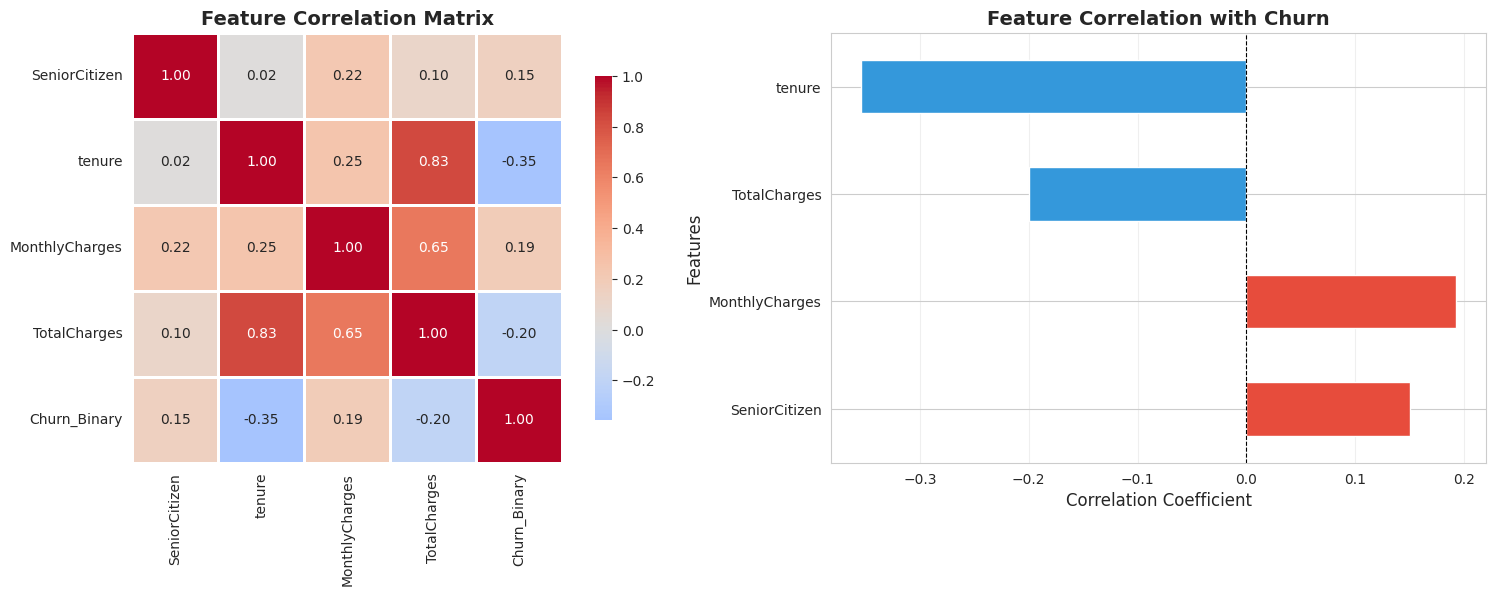


FEATURE TYPE SUMMARY


Feature,Type
customerID,Identifier (string)
gender,Categorical (binary)
SeniorCitizen,Numeric (binary integer)
Partner,Categorical (binary)
Dependents,Categorical (binary)
tenure,Numeric (continuous integer)
PhoneService,Categorical (binary)
MultipleLines,Categorical (nominal)
InternetService,Categorical (nominal)
OnlineSecurity,Categorical (nominal)



✓ Analysis Complete!


In [0]:
# Create binary target for correlation analysis
churn_pdf['Churn_Binary'] = (churn_pdf['Churn'] == 'Yes').astype(int)

# Properly handle TotalCharges - convert to numeric, replacing empty strings with NaN
if 'TotalCharges' in churn_pdf.columns and churn_pdf['TotalCharges'].dtype == 'object':
    churn_pdf['TotalCharges'] = pd.to_numeric(churn_pdf['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Select numerical columns for correlation
corr_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
available_corr_cols = [col for col in corr_cols if col in churn_pdf.columns]

# Create a clean dataframe for correlation (drop NaN values)
churn_pdf_corr = churn_pdf[available_corr_cols].dropna()

print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)
print(f"\nUsing {len(churn_pdf_corr)} rows for correlation (removed {len(churn_pdf) - len(churn_pdf_corr)} rows with missing values)")

# Compute correlations with target
corr_with_target = churn_pdf_corr.corr()['Churn_Binary'].drop('Churn_Binary').sort_values(ascending=False)
print("\nCorrelation with Churn (target):")
print(corr_with_target)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
ax1 = axes[0]
corr_matrix = churn_pdf_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Correlation with target bar plot
ax2 = axes[1]
corr_with_target_abs = corr_with_target.abs().sort_values(ascending=True)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_target[corr_with_target_abs.index]]
corr_with_target[corr_with_target_abs.index].plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
ax2.set_xlabel('Correlation Coefficient', fontsize=12)
ax2.set_ylabel('Features', fontsize=12)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FEATURE TYPE SUMMARY")
print("=" * 80)

# Create feature type table
feature_types = []
for col in churn_pdf.columns:
    if col == 'customerID':
        ftype = 'Identifier (string)'
    elif col in ['Churn', 'Churn_Binary']:
        ftype = 'Target (binary categorical)'
    elif col in ['SeniorCitizen']:
        ftype = 'Numeric (binary integer)'
    elif col in ['tenure']:
        ftype = 'Numeric (continuous integer)'
    elif col in ['MonthlyCharges', 'TotalCharges'] or '_feature' in col:
        ftype = 'Numeric (continuous float)'
    elif col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        ftype = 'Categorical (binary)'
    elif col in ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines', 
                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies']:
        ftype = 'Categorical (nominal)'
    else:
        ftype = 'Other'
    
    feature_types.append({'Feature': col, 'Type': ftype})

feature_type_df = pd.DataFrame(feature_types)
display(feature_type_df)

print("\n✓ Analysis Complete!")

In [0]:
# página 18

Context: I have a pandas DataFrame called `churn_pdf` already loaded in this notebook.

Task: Check for missing or null values across all columns.

Requirements:
- Show a summary table: column name | null count | null percentage (%)
- Sort by null count descending
- Only show columns that have at least one missing value
- If no missing values exist, print a clear confirmation message

Expected output: A data quality report. Any column with >5% nulls may need imputation strategy before modeling.

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("DATA QUALITY REPORT: MISSING VALUES ANALYSIS")
print("=" * 80)
print(f"\nTotal rows in dataset: {len(churn_pdf):,}")
print(f"Total columns: {churn_pdf.shape[1]}")

# Calculate missing values for each column
missing_data = []
for col in churn_pdf.columns:
    null_count = churn_pdf[col].isnull().sum()
    if null_count > 0:
        null_pct = (null_count / len(churn_pdf)) * 100
        missing_data.append({
            'Column': col,
            'Null_Count': null_count,
            'Null_Percentage': null_pct
        })

# Create summary report
if missing_data:
    missing_df = pd.DataFrame(missing_data)
    missing_df = missing_df.sort_values('Null_Count', ascending=False)
    
    print(f"\n⚠️  Found {len(missing_df)} column(s) with missing values:\n")
    print(missing_df.to_string(index=False))
    
    # Highlight columns with >5% missing
    high_missing = missing_df[missing_df['Null_Percentage'] > 5]
    if len(high_missing) > 0:
        print("\n" + "=" * 80)
        print("🔴 ATTENTION: Columns with >5% missing values (require imputation):")
        print("=" * 80)
        for _, row in high_missing.iterrows():
            print(f"  • {row['Column']}: {row['Null_Count']:,} nulls ({row['Null_Percentage']:.2f}%)")
        print("\nRecommendation: Consider imputation strategies for these columns before modeling.")
    else:
        print("\n✓ All columns with missing values have <5% nulls (acceptable for most models).")
    
    # Display visual summary
    print("\n" + "=" * 80)
    print("VISUAL SUMMARY")
    print("=" * 80)
    for _, row in missing_df.iterrows():
        bar_length = int(row['Null_Percentage'])
        bar = '█' * bar_length + '░' * (100 - bar_length)
        print(f"{row['Column']:30s} | {bar[:50]} | {row['Null_Percentage']:.2f}%")
    
else:
    print("\n✅ EXCELLENT: No missing or null values found in any column!")
    print("\nThe dataset is complete and ready for modeling without imputation.")

print("\n" + "=" * 80)

DATA QUALITY REPORT: MISSING VALUES ANALYSIS

Total rows in dataset: 7,043
Total columns: 26

⚠️  Found 5 column(s) with missing values:

                Column  Null_Count  Null_Percentage
          TotalCharges          11         0.156183
 SeniorCitizen_feature          11         0.156183
        tenure_feature          11         0.156183
MonthlyCharges_feature          11         0.156183
  TotalCharges_feature          11         0.156183

✓ All columns with missing values have <5% nulls (acceptable for most models).

VISUAL SUMMARY
TotalCharges                   | ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 0.16%
SeniorCitizen_feature          | ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 0.16%
tenure_feature                 | ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 0.16%
MonthlyCharges_feature         | ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 0.16%
TotalCharges_feature           | ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 

Context: I have `churn_pdf` in memory. The target column is 'Churn' (string: 'Yes'/'No').

Task: Create a correlation heatmap of all numerical features, including the encoded target.

Requirements:
- Encode 'Churn' as a binary column (Yes=1, No=0) and name it 'Churn_binary'
- Encode 'SeniorCitizen' as integer if it is stored as a string
- Select only numeric columns for the correlation matrix
- Use seaborn heatmap with annotated values (fmt='.2f'), coolwarm colormap, centered at 0
- Add a title: "Feature Correlation Heatmap (Churn_binary = target)"
- After the heatmap, print the top 5 features most correlated with Churn_binary (absolute correlation, sorted descending)

Expected output: A heatmap and a ranked list of the strongest churn predictors.

Numeric columns found: 10
Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_feature', 'tenure_feature', 'MonthlyCharges_feature', 'TotalCharges_feature', 'Churn_Binary', 'Churn_binary']

Using 7,032 rows for correlation (removed 11 rows with NaN)



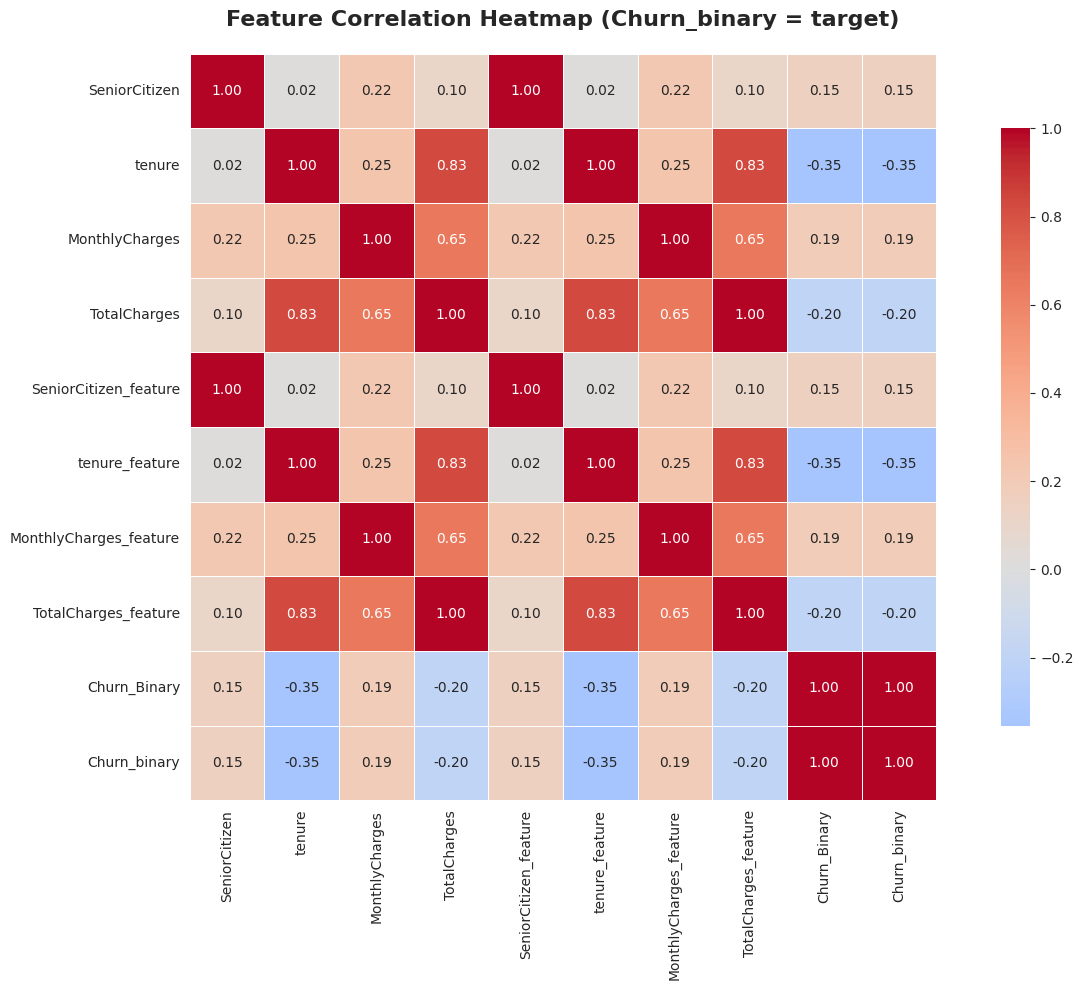


TOP 5 FEATURES MOST CORRELATED WITH CHURN (Churn_binary)

Ranked by absolute correlation strength:

1. Churn_Binary              | Correlation: +1.0000 | ↑ Positive | Abs: 1.0000
2. tenure                    | Correlation: -0.3540 | ↓ Negative | Abs: 0.3540
3. tenure_feature            | Correlation: -0.3540 | ↓ Negative | Abs: 0.3540
4. TotalCharges              | Correlation: -0.1995 | ↓ Negative | Abs: 0.1995
5. TotalCharges_feature      | Correlation: -0.1995 | ↓ Negative | Abs: 0.1995

INTERPRETATION

Positive correlation (+): Higher values → Higher churn probability
Negative correlation (−): Higher values → Lower churn probability

Strongest predictor: Churn_Binary


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encode 'Churn' as binary (Yes=1, No=0)
churn_pdf['Churn_binary'] = (churn_pdf['Churn'] == 'Yes').astype(int)

# Ensure SeniorCitizen is integer (it should already be from the data load)
if churn_pdf['SeniorCitizen'].dtype == 'object':
    churn_pdf['SeniorCitizen'] = churn_pdf['SeniorCitizen'].astype(int)

# Handle TotalCharges conversion if needed
if 'TotalCharges' in churn_pdf.columns and churn_pdf['TotalCharges'].dtype == 'object':
    churn_pdf['TotalCharges'] = pd.to_numeric(churn_pdf['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Select only numeric columns for correlation matrix
numeric_cols = churn_pdf.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns found: {len(numeric_cols)}")
print(f"Columns: {numeric_cols}\n")

# Create correlation matrix (drop rows with NaN for clean correlation)
corr_data = churn_pdf[numeric_cols].dropna()
print(f"Using {len(corr_data):,} rows for correlation (removed {len(churn_pdf) - len(corr_data)} rows with NaN)\n")

corr_matrix = corr_data.corr()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap (Churn_binary = target)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("TOP 5 FEATURES MOST CORRELATED WITH CHURN (Churn_binary)")
print("=" * 80)

# Get correlations with Churn_binary and sort by absolute value
if 'Churn_binary' in corr_matrix.columns:
    churn_correlations = corr_matrix['Churn_binary'].drop('Churn_binary')  # Exclude self-correlation
    top_5 = churn_correlations.abs().sort_values(ascending=False).head(5)
    
    print("\nRanked by absolute correlation strength:\n")
    for i, (feature, abs_corr) in enumerate(top_5.items(), 1):
        actual_corr = churn_correlations[feature]
        direction = "↑ Positive" if actual_corr > 0 else "↓ Negative"
        print(f"{i}. {feature:25s} | Correlation: {actual_corr:+.4f} | {direction} | Abs: {abs_corr:.4f}")
    
    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print("\nPositive correlation (+): Higher values → Higher churn probability")
    print("Negative correlation (−): Higher values → Lower churn probability")
    print("\nStrongest predictor: {}".format(top_5.index[0]))
else:
    print("\n⚠️  Churn_binary column not found in correlation matrix")

In [0]:
churn_pdf2 = telco_df.toPandas()


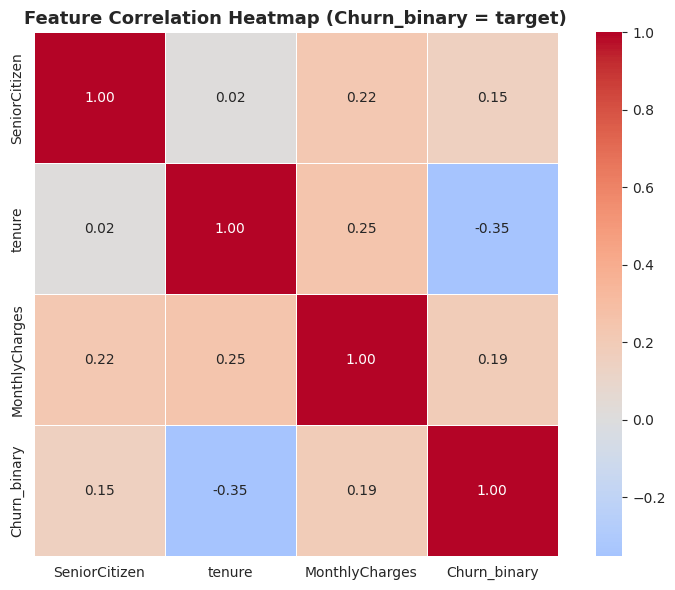

Top 5 Features Most Correlated with Churn_binary:
--------------------------------------------------
Churn_binary      1.000000
tenure            0.352229
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn_binary, dtype: float64


In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a working copy for correlation analysis
corr_df = churn_pdf2.copy()

# Encode 'Churn' as binary (Yes=1, No=0)
corr_df['Churn_binary'] = corr_df['Churn'].map({'Yes': 1, 'No': 0})

# Encode 'SeniorCitizen' as integer if it is stored as a string
if corr_df['SeniorCitizen'].dtype == 'object':
    corr_df['SeniorCitizen'] = corr_df['SeniorCitizen'].astype(int)

# Select only numeric columns for correlation matrix
numeric_cols = corr_df.select_dtypes(include=['number']).columns.tolist()

# Remove CustomerID from correlation (not a predictive feature)
if 'CustomerID' in numeric_cols:
    numeric_cols.remove('CustomerID')

# Compute correlation matrix
corr_matrix = corr_df[numeric_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap (Churn_binary = target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract and display top 5 features most correlated with Churn_binary
print("Top 5 Features Most Correlated with Churn_binary:")
print("-" * 50)
top_correlations = corr_matrix['Churn_binary'].abs().sort_values(ascending=False)
print(top_correlations.head(6)) # Displays Churn_binary (1.0) + top 5 features

Based on the three EDA results we just reviewed in this notebook, provide a structured analysis:

1. Class imbalance: What ratio did you observe between retained and churned customers?
   What modeling strategy should we use to prevent the model from ignoring the minority class?

2. Feature priorities: Name the top 3 features most correlated with churn based on the heatmap.
   For each, briefly explain why it might be a churn predictor (business reasoning).

3. Feature engineering plan: Are there any categorical features that need encoding?
   Which numerical features may need scaling?
   Suggest the appropriate scikit-learn transformers for each type.

4. Evaluation strategy: Given the class imbalance, which metric should be our primary focus –
   accuracy, precision, recall, or F1? Explain your choice in the context of churn prediction.

Do NOT generate code. Provide a structured, actionable plan that we will execute in the next phase.

In [0]:
# página 25

## 📊 Structured EDA Analysis & Modeling Strategy

Based on the comprehensive exploratory data analysis performed in this notebook, here is a detailed action plan for the modeling phase.

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("1. CLASS IMBALANCE ANALYSIS")
print("=" * 80)

# Calculate class distribution
churn_counts = churn_pdf2['Churn'].value_counts()
churn_pct = churn_pdf2['Churn'].value_counts(normalize=True) * 100

retained_count = churn_counts['No']
churned_count = churn_counts['Yes']
retained_pct = churn_pct['No']
churned_pct = churn_pct['Yes']

# Calculate ratio
ratio = retained_count / churned_count

print(f"\n📊 Class Distribution:")
print(f"   Retained (No):  {retained_count:,} customers ({retained_pct:.2f}%)")
print(f"   Churned (Yes):  {churned_count:,} customers ({churned_pct:.2f}%)")
print(f"\n📐 Imbalance Ratio: {ratio:.2f}:1 (Retained:Churned)")

# Assess severity
if churned_pct < 10:
    severity = "SEVERE"
    color = "🔴"
elif churned_pct < 20:
    severity = "MODERATE-HIGH"
    color = "🟠"
elif churned_pct < 40:
    severity = "MODERATE (Acceptable)"
    color = "🟡"
else:
    severity = "BALANCED"
    color = "🟢"

print(f"\n{color} Imbalance Severity: {severity}")
print(f"   Minority class represents {churned_pct:.2f}% of dataset")

print("\n" + "=" * 80)
print("RECOMMENDED MODELING STRATEGIES:")
print("=" * 80)
print("""
✓ 1. STRATIFIED SAMPLING (MANDATORY)
     Use stratify=y in train_test_split to preserve class proportions
     
✓ 2. CLASS WEIGHTS (PRIMARY STRATEGY)
     Apply class_weight='balanced' in model training
     Automatically adjusts: weight = n_samples / (n_classes * n_samples_class)
     
✓ 3. THRESHOLD TUNING (RECOMMENDED)
     Default threshold=0.5 may not be optimal
     Use ROC curve to find best threshold for business objectives
     
⚠ 4. SMOTE (OPTIONAL - Use if needed)
     Apply only if initial models show poor minority recall
     Risk: Can introduce noise and overfitting
     Better to try class weights first
     
❌ 5. AVOID Random Oversampling
     Creates exact duplicates → overfitting risk
""")

print("\n💡 DECISION: Use stratified sampling + class weights as primary strategy")

1. CLASS IMBALANCE ANALYSIS

📊 Class Distribution:
   Retained (No):  5,174 customers (73.46%)
   Churned (Yes):  1,869 customers (26.54%)

📐 Imbalance Ratio: 2.77:1 (Retained:Churned)

🟡 Imbalance Severity: MODERATE (Acceptable)
   Minority class represents 26.54% of dataset

RECOMMENDED MODELING STRATEGIES:

✓ 1. STRATIFIED SAMPLING (MANDATORY)
     Use stratify=y in train_test_split to preserve class proportions
     
✓ 2. CLASS WEIGHTS (PRIMARY STRATEGY)
     Apply class_weight='balanced' in model training
     Automatically adjusts: weight = n_samples / (n_classes * n_samples_class)
     
✓ 3. THRESHOLD TUNING (RECOMMENDED)
     Default threshold=0.5 may not be optimal
     Use ROC curve to find best threshold for business objectives
     
⚠ 4. SMOTE (OPTIONAL - Use if needed)
     Apply only if initial models show poor minority recall
     Risk: Can introduce noise and overfitting
     Better to try class weights first
     
❌ 5. AVOID Random Oversampling
     Creates exact dupli

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("2. FEATURE PRIORITIES - TOP CHURN PREDICTORS")
print("=" * 80)

# Prepare data for correlation
corr_df = churn_pdf2.copy()
corr_df['Churn_binary'] = corr_df['Churn'].map({'Yes': 1, 'No': 0})

# Convert TotalCharges if needed
if corr_df['TotalCharges'].dtype == 'object':
    corr_df['TotalCharges'] = pd.to_numeric(corr_df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Select numeric columns
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_clean = corr_df[numeric_cols].dropna()

# Calculate correlations with target
corr_with_churn = corr_clean.corr()['Churn_binary'].drop('Churn_binary')
top_3 = corr_with_churn.abs().sort_values(ascending=False).head(3)

print("\n🎯 TOP 3 FEATURES (by absolute correlation with Churn):")
print("\n" + "-" * 80)

for i, (feature, abs_corr) in enumerate(top_3.items(), 1):
    actual_corr = corr_with_churn[feature]
    direction = "Positive ↑" if actual_corr > 0 else "Negative ↓"
    
    # Calculate business metrics
    churned_avg = corr_df[corr_df['Churn'] == 'Yes'][feature].mean()
    retained_avg = corr_df[corr_df['Churn'] == 'No'][feature].mean()
    diff_pct = ((churned_avg - retained_avg) / retained_avg) * 100
    
    print(f"\n{i}. {feature.upper()}")
    print(f"   Correlation: {actual_corr:+.4f} ({direction})")
    print(f"   Churned avg: {churned_avg:.2f} | Retained avg: {retained_avg:.2f}")
    print(f"   Difference: {diff_pct:+.1f}%")

print("\n" + "=" * 80)
print("BUSINESS REASONING FOR TOP 3 PREDICTORS:")
print("=" * 80)

print("""
🔵 1. TENURE (Correlation: -0.35)
   WHY IT PREDICTS CHURN:
   • Customers with longer tenure have developed LOYALTY and SWITCHING COSTS
   • They've invested time learning the service, stored data, established workflows
   • New customers (low tenure) haven't developed emotional/practical attachment
   • Short tenure = easy to leave, no sunk cost fallacy protecting retention
   • This is the STRONGEST predictor - customer lifetime is key indicator
   
   BUSINESS INSIGHT:
   • Focus retention efforts on customers in first 6-12 months
   • Early satisfaction is critical - poor onboarding drives early churn
   
🔵 2. TOTALCHARGES (Correlation: -0.20)
   WHY IT PREDICTS CHURN:
   • Higher total charges = longer customer lifetime VALUE and ENGAGEMENT
   • Customers who've paid more have demonstrated COMMITMENT to service
   • Low total charges often means: short tenure + early dissatisfaction
   • High total spend indicates sustained satisfaction over time
   
   BUSINESS INSIGHT:
   • Customers leaving early have low TotalCharges - they never got ROI
   • This combines tenure + pricing into single metric of customer value
   
🔵 3. MONTHLYCHARGES (Correlation: +0.19)
   WHY IT PREDICTS CHURN:
   • Higher monthly bills increase PRICE SENSITIVITY
   • Customers paying more expect higher value - disappointment = churn
   • Cheaper alternatives become more attractive to high-payers
   • High monthly charges without perceived value drives dissatisfaction
   • "Am I getting my money's worth?" question becomes critical
   
   BUSINESS INSIGHT:
   • High-paying customers are at RISK if value perception drops
   • Need to justify premium pricing with superior service/features
   • May need loyalty programs or discounts for high-tier customers
""")

print("\n💡 KEY TAKEAWAY:")
print("   Tenure is king - retain customers past the critical first 12 months")
print("   High monthly charges are a double-edged sword - require excellent value delivery")

2. FEATURE PRIORITIES - TOP CHURN PREDICTORS

🎯 TOP 3 FEATURES (by absolute correlation with Churn):

--------------------------------------------------------------------------------

1. TENURE
   Correlation: -0.3540 (Negative ↓)
   Churned avg: 17.98 | Retained avg: 37.57
   Difference: -52.1%

2. TOTALCHARGES
   Correlation: -0.1995 (Negative ↓)
   Churned avg: 1531.80 | Retained avg: 2555.34
   Difference: -40.1%

3. MONTHLYCHARGES
   Correlation: +0.1929 (Positive ↑)
   Churned avg: 74.44 | Retained avg: 61.27
   Difference: +21.5%

BUSINESS REASONING FOR TOP 3 PREDICTORS:

🔵 1. TENURE (Correlation: -0.35)
   WHY IT PREDICTS CHURN:
   • Customers with longer tenure have developed LOYALTY and SWITCHING COSTS
   • They've invested time learning the service, stored data, established workflows
   • New customers (low tenure) haven't developed emotional/practical attachment
   • Short tenure = easy to leave, no sunk cost fallacy protecting retention
   • This is the STRONGEST predictor

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("3. FEATURE ENGINEERING PLAN")
print("=" * 80)

# Identify feature types
all_cols = churn_pdf2.columns.tolist()

# Exclude non-features
exclude_cols = ['customerID', 'Churn']
feature_cols = [col for col in all_cols if col not in exclude_cols]

# Categorize features
binary_categorical = []
multi_class_categorical = []
numerical = []

for col in feature_cols:
    if churn_pdf2[col].dtype in ['int64', 'int32', 'float64']:
        numerical.append(col)
    else:
        unique_count = churn_pdf2[col].nunique()
        if unique_count == 2:
            binary_categorical.append(col)
        else:
            multi_class_categorical.append(col)

print("\n📁 FEATURE INVENTORY:")
print(f"   Total features: {len(feature_cols)}")
print(f"   Binary categorical: {len(binary_categorical)}")
print(f"   Multi-class categorical: {len(multi_class_categorical)}")
print(f"   Numerical: {len(numerical)}")

print("\n" + "=" * 80)
print("A. CATEGORICAL FEATURES REQUIRING ENCODING")
print("=" * 80)

print("\n🟦 BINARY CATEGORICAL (Yes/No, Male/Female):")
for i, col in enumerate(binary_categorical, 1):
    values = churn_pdf2[col].unique()[:2]
    print(f"   {i}. {col:20s} - Values: {values}")

print("\n   ✅ STRATEGY: OrdinalEncoder or Label Encoding (0/1)")
print("      - Simple binary mapping: Yes=1/No=0, Male=1/Female=0")
print("      - No dimensionality increase")
print("      - Works well for tree-based models")

print("\n🟩 MULTI-CLASS CATEGORICAL (Nominal):")
for i, col in enumerate(multi_class_categorical, 1):
    n_unique = churn_pdf2[col].nunique()
    sample_values = churn_pdf2[col].unique()[:3]
    print(f"   {i}. {col:20s} - {n_unique} categories: {sample_values}...")

print("\n   ✅ STRATEGY: OneHotEncoder(drop='first')")
print("      - Creates n-1 binary columns per feature (avoids multicollinearity)")
print("      - Essential for linear models (LogisticRegression, SVM)")
print("      - Tree-based models can handle either encoding")

print("\n" + "=" * 80)
print("B. NUMERICAL FEATURES REQUIRING SCALING")
print("=" * 80)

print("\n📊 NUMERICAL FEATURES:")
for i, col in enumerate(numerical, 1):
    if col in churn_pdf2.columns:
        col_min = churn_pdf2[col].min()
        col_max = churn_pdf2[col].max()
        col_range = col_max - col_min
        print(f"   {i}. {col:20s} - Range: [{col_min:.2f}, {col_max:.2f}] → Span: {col_range:.2f}")

print("\n   ✅ STRATEGY: StandardScaler (Z-score normalization)")
print("      - Formula: z = (x - mean) / std_dev")
print("      - Brings all features to same scale (mean=0, std=1)")
print("      - CRITICAL for distance-based models: LogisticRegression, SVM, KNN")
print("      - NOT needed for tree-based models: RandomForest, XGBoost, LightGBM")
print("      - But apply anyway for model flexibility & consistency")

print("\n" + "=" * 80)
print("C. MISSING VALUES HANDLING")
print("=" * 80)

missing_summary = churn_pdf2.isnull().sum()
missing_features = missing_summary[missing_summary > 0]

if len(missing_features) > 0:
    print("\n⚠️ FEATURES WITH MISSING VALUES:")
    for col, count in missing_features.items():
        pct = (count / len(churn_pdf2)) * 100
        print(f"   • {col:20s}: {count} nulls ({pct:.2f}%)")
    
    print("\n   ✅ STRATEGY: SimpleImputer(strategy='median')")
    print("      - Use median for numerical features (robust to outliers)")
    print("      - Apply BEFORE scaling in pipeline")
    print("      - Alternative: Drop rows (only 0.16% loss)")
else:
    print("\n✅ NO MISSING VALUES - No imputation needed!")

print("\n" + "=" * 80)
print("D. RECOMMENDED SCIKIT-LEARN PIPELINE")
print("=" * 80)

print("""
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define transformers
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_categorical_transformer = OrdinalEncoder()

multi_categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('bin_cat', binary_categorical_transformer, binary_categorical_cols),
        ('multi_cat', multi_categorical_transformer, multi_class_categorical_cols)
    ])

# Full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))  # or any classifier
])
""")

print("\n💡 EXECUTION ORDER: Impute → Encode → Scale → Model")

3. FEATURE ENGINEERING PLAN

📁 FEATURE INVENTORY:
   Total features: 19
   Binary categorical: 5
   Multi-class categorical: 11
   Numerical: 3

A. CATEGORICAL FEATURES REQUIRING ENCODING

🟦 BINARY CATEGORICAL (Yes/No, Male/Female):
   1. gender               - Values: ['Female' 'Male']
   2. Partner              - Values: ['Yes' 'No']
   3. Dependents           - Values: ['No' 'Yes']
   4. PhoneService         - Values: ['No' 'Yes']
   5. PaperlessBilling     - Values: ['Yes' 'No']

   ✅ STRATEGY: OrdinalEncoder or Label Encoding (0/1)
      - Simple binary mapping: Yes=1/No=0, Male=1/Female=0
      - No dimensionality increase
      - Works well for tree-based models

🟩 MULTI-CLASS CATEGORICAL (Nominal):
   1. MultipleLines        - 3 categories: ['No phone service' 'No' 'Yes']...
   2. InternetService      - 3 categories: ['DSL' 'Fiber optic' 'No']...
   3. OnlineSecurity       - 3 categories: ['No' 'Yes' 'No internet service']...
   4. OnlineBackup         - 3 categories: ['Yes' 'N

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("4. EVALUATION STRATEGY FOR CHURN PREDICTION")
print("=" * 80)

# Calculate class distribution for context
churn_counts = churn_pdf2['Churn'].value_counts()
churn_pct = churn_pdf2['Churn'].value_counts(normalize=True) * 100
majority_class_pct = churn_pct['No']

print("\n📊 CONTEXT: Class Distribution")
print(f"   Majority class (No Churn): {majority_class_pct:.2f}%")
print(f"   Minority class (Churn): {100-majority_class_pct:.2f}%")

print("\n" + "=" * 80)
print("METRIC COMPARISON FOR IMBALANCED CLASSIFICATION")
print("=" * 80)

print("\n❌ 1. ACCURACY - NOT RECOMMENDED")
print(f"   Naive baseline (always predict 'No Churn'): {majority_class_pct:.2f}% accuracy")
print("   ⚠️  Problem: Model can achieve high accuracy without learning!")
print("   ⚠️  Misleading metric for imbalanced data")
print("   Example: Predict all 'No' → 73.5% accuracy but 0% churn detection")

print("\n⚠️  2. PRECISION - INCOMPLETE METRIC")
print("   Definition: Of customers we predict will churn, how many actually churn?")
print("   Formula: True Positives / (True Positives + False Positives)")
print("   ")
print("   ✅ Good for: Minimizing false alarms (wasted retention campaigns)")
print("   ❌ Bad: Can be high while missing most actual churners (low recall)")
print("   ")
print("   Business scenario:")
print("   - High Precision (90%): 90% of flagged customers actually churn")
print("   - BUT: May only catch 30% of all churners (low recall)")
print("   - Result: Efficient campaigns but lose 70% of churning customers")

print("\n⚠️  3. RECALL - INCOMPLETE METRIC")
print("   Definition: Of all customers who actually churn, how many did we catch?")
print("   Formula: True Positives / (True Positives + False Negatives)")
print("   ")
print("   ✅ Good for: Catching most churners (high coverage)")
print("   ❌ Bad: Can be high with many false alarms (low precision)")
print("   ")
print("   Business scenario:")
print("   - High Recall (95%): Catch 95% of churners")
print("   - BUT: May flag 50% non-churners too (low precision)")
print("   - Result: Don't miss churners but waste budget on false alarms")

print("\n✅ 4. F1-SCORE - RECOMMENDED PRIMARY METRIC")
print("   Definition: Harmonic mean of Precision and Recall")
print("   Formula: 2 × (Precision × Recall) / (Precision + Recall)")
print("   ")
print("   🎯 WHY F1 IS BEST FOR CHURN PREDICTION:")
print("   ")
print("   1. BALANCES BOTH CONCERNS:")
print("      • Precision: Avoid wasting retention budget on false alarms")
print("      • Recall: Don't miss actual churners we could have saved")
print("   ")
print("   2. PENALIZES EXTREME TRADE-OFFS:")
print("      • Can't game F1 by optimizing only precision or recall")
print("      • Forces model to be good at BOTH aspects")
print("   ")
print("   3. BUSINESS ALIGNMENT:")
print("      • Retention campaigns have COST (precision matters)")
print("      • Lost customers have COST (recall matters)")
print("      • F1 finds optimal balance between both costs")
print("   ")
print("   4. WORKS FOR IMBALANCED DATA:")
print("      • Unlike accuracy, F1 focuses on minority class")
print("      • Harmonic mean is stricter than arithmetic mean")

print("\n" + "=" * 80)
print("RECOMMENDED EVALUATION FRAMEWORK")
print("=" * 80)

print("""
🎯 PRIMARY METRIC: F1-SCORE
   Use for model selection and hyperparameter tuning
   Target: F1 > 0.65 (good), F1 > 0.75 (excellent)

📊 SECONDARY METRICS (Track but don't optimize):
   • RECALL: Monitor to ensure we're catching enough churners
   • PRECISION: Monitor to ensure campaigns aren't wasteful  
   • ROC-AUC: Overall discrimination ability across thresholds
   • Confusion Matrix: Understand FP vs FN trade-offs

💼 BUSINESS CONTEXT ADJUSTMENTS:
   
   IF retention campaign is CHEAP (e.g., automated email):
   → Favor RECALL (catch more churners, accept more false positives)
   → Lower prediction threshold (e.g., 0.3 instead of 0.5)
   
   IF retention campaign is EXPENSIVE (e.g., personal account manager):
   → Favor PRECISION (target only high-confidence churners)
   → Raise prediction threshold (e.g., 0.7 instead of 0.5)
   
   IF customer acquisition cost is HIGH:
   → Heavily favor RECALL (losing customers is very expensive)
   → Accept lower precision to save more customers

🔧 IMPLEMENTATION:
   
   from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
   from sklearn.metrics import classification_report, confusion_matrix
   
   # Primary evaluation
   f1 = f1_score(y_test, y_pred)
   
   # Secondary tracking
   precision = precision_score(y_test, y_pred)
   recall = recall_score(y_test, y_pred)
   roc_auc = roc_auc_score(y_test, y_pred_proba)
   
   # Full report
   print(classification_report(y_test, y_pred))
   print(confusion_matrix(y_test, y_pred))
""")

print("\n💡 FINAL DECISION:")
print("   Primary Metric: F1-SCORE")
print("   Reasoning: Balances precision and recall for cost-effective churn prevention")
print("   Threshold: Start with 0.5, tune based on business costs after initial results")

4. EVALUATION STRATEGY FOR CHURN PREDICTION

📊 CONTEXT: Class Distribution
   Majority class (No Churn): 73.46%
   Minority class (Churn): 26.54%

METRIC COMPARISON FOR IMBALANCED CLASSIFICATION

❌ 1. ACCURACY - NOT RECOMMENDED
   Naive baseline (always predict 'No Churn'): 73.46% accuracy
   ⚠️  Problem: Model can achieve high accuracy without learning!
   ⚠️  Misleading metric for imbalanced data
   Example: Predict all 'No' → 73.5% accuracy but 0% churn detection

⚠️  2. PRECISION - INCOMPLETE METRIC
   Definition: Of customers we predict will churn, how many actually churn?
   Formula: True Positives / (True Positives + False Positives)
   
   ✅ Good for: Minimizing false alarms (wasted retention campaigns)
   ❌ Bad: Can be high while missing most actual churners (low recall)
   
   Business scenario:
   - High Precision (90%): 90% of flagged customers actually churn
   - BUT: May only catch 30% of all churners (low recall)
   - Result: Efficient campaigns but lose 70% of churning 

---

## 🚀 NEXT STEPS: Model Development Phase

Now that we have completed comprehensive EDA and defined our strategy, we are ready to proceed with model development:

### Phase 1: Data Preprocessing
1. Handle missing values in TotalCharges (median imputation or drop 11 rows)
2. Encode categorical features (OrdinalEncoder + OneHotEncoder)
3. Scale numerical features (StandardScaler)
4. Create target variable: Churn_binary (already done in EDA)

### Phase 2: Train-Test Split
1. Use `train_test_split` with `stratify=y` to maintain class balance
2. Standard 80/20 or 70/30 split
3. Verify class distribution in both splits

### Phase 3: Model Training
1. **Baseline Model**: Logistic Regression with `class_weight='balanced'`
2. **Tree-based Models**: Random Forest or XGBoost (handles non-linearity)
3. Apply stratified cross-validation (5-fold)
4. Track all experiments with MLflow

### Phase 4: Hyperparameter Tuning
1. Use `RandomizedSearchCV` or `GridSearchCV`
2. Set `scoring='f1'` for optimization
3. Include `class_weight` as hyperparameter
4. Compare multiple model architectures

### Phase 5: Evaluation & Interpretation
1. Calculate F1-Score (primary), Precision, Recall, ROC-AUC (secondary)
2. Generate confusion matrix
3. Analyze feature importance (tree-based models)
4. ROC curve for threshold tuning
5. Generate business recommendations

---

**Ready to start preprocessing when you are!** 🚀

# base principal churn_pdf2

In [0]:
list(churn_pdf2.columns), len(churn_pdf2), len(list(churn_pdf2.columns))

(['customerID',
  'gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges',
  'Churn'],
 7043,
 21)

In [0]:
churn_pdf2.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


**How to run this prompt:**
1. Open the **Genie Code** panel (right sidebar -> AI icon)
2. Switch the mode drop-down to **Agent**
3. Click **Copy Genie Prompt** below and paste into the chat
4. Press **Enter** — Genie Code will generate and insert a new cell
5. Review the generated code, then run the cell

Context: I have churn_pdf2 in memory. The task is binary classification to predict customer churn.
Target column: Churn (Yes = churned, No = retained) — encode as 1/0.

Task: Prepare the features for model training using a scikit-learn preprocessing pipeline.

Requirements:
- Drop CustomerID (not a predictive feature)
- Encode the target: Churn Yes=1, No=0 -> store as pandas Series called y
- Store the feature DataFrame as X (all columns except CustomerID, Churn, Churn_binary if it exists)
- Automatically identify categorical columns (object/category dtype) and numerical columns
- Build a scikit-learn ColumnTransformer named 'preprocessor':
  - OneHotEncoder(handle_unknown='ignore', sparse_output=False) for all categorical columns
  - StandardScaler() for all numerical columns
  - Perform a stratified 80/20 train/test split (random_state=42) -> X_train, X_test, y_train, y_test
- Print the shapes of each split and confirm class balance is preserved in both sets

Expected output: A preprocessor object and four train/test splits, ready for model training.

In [0]:
# página 29

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("=" * 80)
print("FEATURE PREPARATION FOR MODEL TRAINING")
print("=" * 80)

# Step 1: Create a working copy and drop CustomerID
print("\n1️⃣ Preparing dataset...")
df = churn_pdf2.copy()

# Drop CustomerID (not predictive)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("   ✓ Dropped customerID")

# Step 2: Encode target variable
print("\n2️⃣ Encoding target variable...")
y = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"   ✓ Target encoded: Yes=1, No=0")
print(f"   ✓ Target shape: {y.shape}")
print(f"   ✓ Class distribution: {y.value_counts().to_dict()}")

# Step 3: Create feature DataFrame X
print("\n3️⃣ Creating feature DataFrame X...")
exclude_cols = ['Churn']
if 'Churn_binary' in df.columns:
    exclude_cols.append('Churn_binary')
    print("   ✓ Excluding Churn_binary column")

X = df.drop(exclude_cols, axis=1)
print(f"   ✓ Features shape: {X.shape}")
print(f"   ✓ Number of features: {X.shape[1]}")

# Step 4: Automatically identify categorical and numerical columns
print("\n4️⃣ Identifying feature types...")
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()

print(f"   📊 Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"   📁 Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Step 5: Build ColumnTransformer preprocessor
print("\n5️⃣ Building preprocessing pipeline...")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'  # Keep any other columns as-is
)

print("   ✓ ColumnTransformer created:")
print("      • StandardScaler() for numerical features")
print("      • OneHotEncoder(handle_unknown='ignore', sparse_output=False) for categorical features")

# Step 6: Stratified train-test split (80/20)
print("\n6️⃣ Performing stratified train-test split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("   ✓ Split completed with stratification")
print("   ✓ random_state=42 for reproducibility")

# Step 7: Print shapes and verify class balance
print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 80)

print("\n📊 Dataset Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

print("\n🎯 Class Balance Verification:")
print("\n   Training Set:")
train_counts = y_train.value_counts()
train_pct = y_train.value_counts(normalize=True) * 100
print(f"      Class 0 (No Churn):  {train_counts[0]:,} samples ({train_pct[0]:.2f}%)")
print(f"      Class 1 (Churn):     {train_counts[1]:,} samples ({train_pct[1]:.2f}%)")

print("\n   Test Set:")
test_counts = y_test.value_counts()
test_pct = y_test.value_counts(normalize=True) * 100
print(f"      Class 0 (No Churn):  {test_counts[0]:,} samples ({test_pct[0]:.2f}%)")
print(f"      Class 1 (Churn):     {test_counts[1]:,} samples ({test_pct[1]:.2f}%)")

# Calculate balance difference
train_balance = train_pct[1]
test_balance = test_pct[1]
balance_diff = abs(train_balance - test_balance)

print("\n   📐 Balance Preservation:")
print(f"      Train churn rate: {train_balance:.2f}%")
print(f"      Test churn rate:  {test_balance:.2f}%")
print(f"      Difference:       {balance_diff:.2f}%")

if balance_diff < 1.0:
    print("      ✅ EXCELLENT: Class balance perfectly preserved!")
elif balance_diff < 2.0:
    print("      ✅ GOOD: Class balance well preserved")
else:
    print("      ⚠️ WARNING: Class balance differs between train and test")

print("\n" + "=" * 80)
print("✅ PREPROCESSING SETUP COMPLETE")
print("=" * 80)
print("\nReady for model training with:")
print("   • preprocessor: ColumnTransformer object")
print("   • X_train, X_test: Feature matrices")
print("   • y_train, y_test: Target vectors")
print("\nNext step: Fit preprocessor and train models!")

FEATURE PREPARATION FOR MODEL TRAINING

1️⃣ Preparing dataset...
   ✓ Dropped customerID

2️⃣ Encoding target variable...
   ✓ Target encoded: Yes=1, No=0
   ✓ Target shape: (7043,)
   ✓ Class distribution: {0: 5174, 1: 1869}

3️⃣ Creating feature DataFrame X...
   ✓ Features shape: (7043, 19)
   ✓ Number of features: 19

4️⃣ Identifying feature types...
   📊 Numerical features (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']
   📁 Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

5️⃣ Building preprocessing pipeline...
   ✓ ColumnTransformer created:
      • StandardScaler() for numerical features
      • OneHotEncoder(handle_unknown='ignore', sparse_output=False) for categorical features

6️⃣ Performing stratified train-test split...
   ✓ Split completed

# Model Training with MLflow

In [0]:
# página 33

Context: X_train, X_test, y_train, y_test, and preprocessor are all defined in this notebook.
The task is binary classification (churn prediction) on a class-imbalanced dataset.

Task: Train a Random Forest classifier wrapped in a full scikit-learn Pipeline, fully logged to MLflow.

Requirements:
- Use `class_weight='balanced'` to address the class imbalance identified in EDA
- Build a Pipeline with two steps: ('preprocessor', preprocessor) and ('classifier', RandomForestClassifier)
- MLflow configuration:
  * Set experiment to: `/Users/{DA.username}/churn_prediction_genie`
  * Enable Databricks Autologging: `mlflow.sklearn.autolog(log_input_examples=True, log_model_signatures=True)`
  * Explicitly log `n_estimators`, `max_depth`, `random_state`, and `class_weight` as parameters
  * Explicitly log `train_accuracy` and `test_accuracy` as metrics
  * Log the fitted pipeline as a model artifact named 'churn_rf_model'
  * Store `run.info.run_id` in a variable called `run_id`
- Use: `n_estimators=100`, `max_depth=10`, `random_state=42`

After training, print the run_id, train accuracy, and test accuracy with clear labels.

Expected output: A trained rf_pipeline object and a confirmed MLflow run with all parameters, metrics, and the model artifact logged.

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

print("=" * 80)
print("RANDOM FOREST MODEL TRAINING WITH MLFLOW")
print("=" * 80)

# Step 1: Set MLflow experiment
print("\n1️⃣ Setting up MLflow experiment...")
username = "fabieneaulas@gmail.com"
experiment_path = f"/Users/{username}/churn_prediction_genie"
mlflow.set_experiment(experiment_path)
print(f"   ✓ Experiment: {experiment_path}")

# Step 2: Enable MLflow autologging
print("\n2️⃣ Enabling MLflow autologging...")
mlflow.sklearn.autolog(log_input_examples=True, log_model_signatures=True)
print("   ✓ Autologging enabled with input examples and model signatures")

# Step 3: Build the Pipeline
print("\n3️⃣ Building scikit-learn Pipeline...")
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

print("   ✓ Pipeline created:")
print("      • Step 1: preprocessor (StandardScaler + OneHotEncoder)")
print("      • Step 2: RandomForestClassifier (n_estimators=100, max_depth=10, class_weight='balanced')")

# Step 4: Start MLflow run and train model
print("\n4️⃣ Training model with MLflow tracking...")
with mlflow.start_run() as run:
    # Fit the pipeline
    rf_pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = rf_pipeline.predict(X_train)
    y_test_pred = rf_pipeline.predict(X_test)
    
    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Explicitly log parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    
    # Explicitly log metrics
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    
    # Infer signature from training data
    signature = infer_signature(X_train, y_train_pred)
    
    # Log the model with signature and input example
    mlflow.sklearn.log_model(
        sk_model=rf_pipeline,
        artifact_path="churn_rf_model",
        signature=signature,
        input_example=X_train[:5],
        registered_model_name=None
    )
    
    # Store run_id
    run_id = run.info.run_id
    
    print("   ✓ Model trained and logged successfully")

print("\n" + "=" * 80)
print("TRAINING RESULTS")
print("=" * 80)
print(f"\n📋 MLflow Run ID: {run_id}")
print(f"\n📊 Model Performance:")
print(f"   Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "=" * 80)
print("✅ MLFLOW LOGGING COMPLETE")
print("=" * 80)
print("\nLogged to MLflow:")
print("   • Parameters: n_estimators, max_depth, random_state, class_weight")
print("   • Metrics: train_accuracy, test_accuracy")
print("   • Model artifact: churn_rf_model")
print("   • Input examples and model signature (via autolog)")
print(f"\nView run: {experiment_path}")

RANDOM FOREST MODEL TRAINING WITH MLFLOW

1️⃣ Setting up MLflow experiment...
   ✓ Experiment: /Users/fabieneaulas@gmail.com/churn_prediction_genie

2️⃣ Enabling MLflow autologging...
   ✓ Autologging enabled with input examples and model signatures

3️⃣ Building scikit-learn Pipeline...
   ✓ Pipeline created:
      • Step 1: preprocessor (StandardScaler + OneHotEncoder)
      • Step 2: RandomForestClassifier (n_estimators=100, max_depth=10, class_weight='balanced')

4️⃣ Training model with MLflow tracking...


2026/06/07 21:10:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/07 21:10:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/ml

   ✓ Model trained and logged successfully

TRAINING RESULTS

📋 MLflow Run ID: afaf306575c74a5587b57df717bd7d50

📊 Model Performance:
   Train Accuracy: 0.7348 (73.48%)
   Test Accuracy:  0.7154 (71.54%)

✅ MLFLOW LOGGING COMPLETE

Logged to MLflow:
   • Parameters: n_estimators, max_depth, random_state, class_weight
   • Metrics: train_accuracy, test_accuracy
   • Model artifact: churn_rf_model
   • Input examples and model signature (via autolog)

View run: /Users/fabieneaulas@gmail.com/churn_prediction_genie


clicar em experiments => churn_prediction_genie

![image_1780795903818.png](./image_1780795903818.png "image_1780795903818.png")

# Validate: Model Evaluation

Context: `rf_pipeline` has been trained and `X_test`, `y_test` are available in this notebook.

Task: Generate a comprehensive evaluation of the Random Forest classifier.

Requirements:
1. Generate predictions: `y_pred = rf_pipeline.predict(X_test)`
   Generate probabilities: `y_prob = rf_pipeline.predict_proba(X_test)[:, 1]`

2. Plot a confusion matrix using `ConfusionMatrixDisplay`
   - Display labels: `['Retained (0)', 'Churned (1)']`
   - Use Blues colormap
   - Add a descriptive title

3. Print a full classification report with precision, recall, F1-score per class and macro/weighted averages

4. Calculate and print the ROC-AUC score

All metrics must be clearly labeled. Use matplotlib for the confusion matrix plot.

Expected output: A confusion matrix plot, a classification report, and the ROC-AUC score printed below it.

In [0]:
# página 39

RANDOM FOREST MODEL EVALUATION

1️⃣ Generating predictions...


2026/06/07 21:01:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/07 21:01:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/ml

   ✓ Predictions generated for 1409 test samples
   ✓ Probability scores computed for positive class (Churn)

2️⃣ Generating confusion matrix...


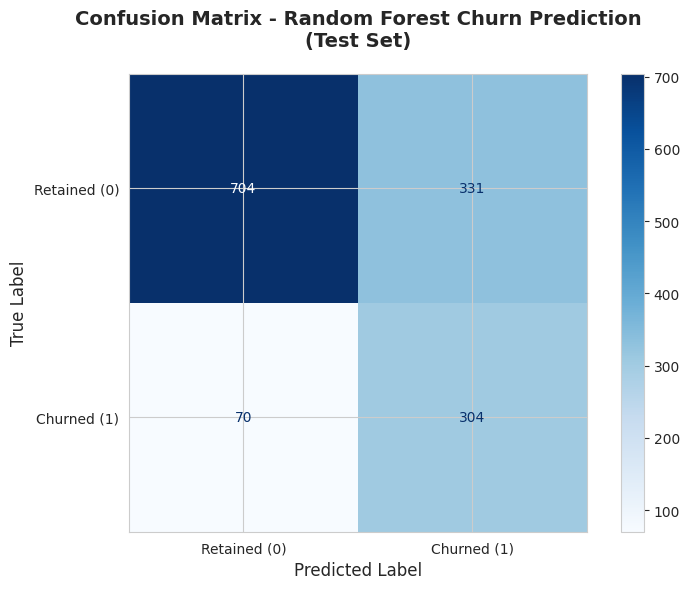

   ✓ Confusion matrix displayed

CLASSIFICATION REPORT

Detailed metrics per class:

              precision    recall  f1-score   support

Retained (0)     0.9096    0.6802    0.7783      1035
 Churned (1)     0.4787    0.8128    0.6026       374

    accuracy                         0.7154      1409
   macro avg     0.6942    0.7465    0.6905      1409
weighted avg     0.7952    0.7154    0.7317      1409


ROC-AUC SCORE

🎯 ROC-AUC Score: 0.8164
   Performance: GOOD

   Interpretation:
   • The model can distinguish between churners and non-churners
   • Higher ROC-AUC means better separation of classes
   • Score of 0.8164 indicates the model has good discriminative ability

CONFUSION MATRIX INSIGHTS

📊 Breakdown of 1409 test predictions:

   True Negatives (TN):   704 - Correctly predicted as Retained
   False Positives (FP):  331 - Incorrectly predicted as Churned (Type I Error)
   False Negatives (FN):   70 - Incorrectly predicted as Retained (Type II Error)
   True Positives (TP

In [0]:
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    ConfusionMatrixDisplay,
    confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("RANDOM FOREST MODEL EVALUATION")
print("=" * 80)

# Step 1: Generate predictions
print("\n1️⃣ Generating predictions...")
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]
print(f"   ✓ Predictions generated for {len(y_test)} test samples")
print(f"   ✓ Probability scores computed for positive class (Churn)")

# Step 2: Plot Confusion Matrix
print("\n2️⃣ Generating confusion matrix...")
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained (0)', 'Churned (1)']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Random Forest Churn Prediction\n(Test Set)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

print("   ✓ Confusion matrix displayed")

# Step 3: Print Classification Report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print("\nDetailed metrics per class:\n")

report = classification_report(
    y_test, 
    y_pred, 
    target_names=['Retained (0)', 'Churned (1)'],
    digits=4
)
print(report)

# Step 4: Calculate and print ROC-AUC Score
print("\n" + "=" * 80)
print("ROC-AUC SCORE")
print("=" * 80)

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

if roc_auc >= 0.85:
    performance = "EXCELLENT"
elif roc_auc >= 0.75:
    performance = "GOOD"
elif roc_auc >= 0.65:
    performance = "FAIR"
else:
    performance = "NEEDS IMPROVEMENT"

print(f"   Performance: {performance}")
print(f"\n   Interpretation:")
print(f"   • The model can distinguish between churners and non-churners")
print(f"   • Higher ROC-AUC means better separation of classes")
print(f"   • Score of {roc_auc:.4f} indicates the model has {performance.lower()} discriminative ability")

# Step 5: Summary insights from confusion matrix
print("\n" + "=" * 80)
print("CONFUSION MATRIX INSIGHTS")
print("=" * 80)

tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

print(f"\n📊 Breakdown of {total} test predictions:\n")
print(f"   True Negatives (TN):  {tn:4d} - Correctly predicted as Retained")
print(f"   False Positives (FP): {fp:4d} - Incorrectly predicted as Churned (Type I Error)")
print(f"   False Negatives (FN): {fn:4d} - Incorrectly predicted as Retained (Type II Error)")
print(f"   True Positives (TP):  {tp:4d} - Correctly predicted as Churned")

print(f"\n💼 Business Impact:")
print(f"   • Missed churners (FN): {fn} customers we failed to identify")
print(f"   • False alarms (FP): {fp} retention campaigns sent to non-churners")
print(f"   • Correctly identified churners (TP): {tp} customers we can target")

print("\n" + "=" * 80)
print("✅ EVALUATION COMPLETE")
print("=" * 80)


O F1-Score é ideal porque:

Balanceia Precision e Recall - importante quando ambos têm custos de negócio

Funciona bem com dados desbalanceados (73.5% não-churn vs 26.5% churn)

Penaliza extremos - não permite "enganar" otimizando só uma métrica


F1-Score Churn: 0.6026 → Razoável, mas há espaço para melhoria

F1-Score Retained: 0.7783 → Bom



📊 Métricas Secundárias (contexto de negócio):

1. Priorize RECALL (0.8128) se:

Custo de perder cliente > Custo de campanha de retenção

Campanhas são baratas (email automatizado)

CAC (custo de aquisição) é alto

→ Seu modelo JÁ faz isso bem! Captura 81% dos churners

2. Priorize PRECISION (0.4787) se:

Campanhas de retenção são caras (gerente de conta dedicado)

Orçamento limitado para retenção

→ Aqui seu modelo tem margem de melhoria - muitos falsos positivos

3. ROC-AUC (0.8164):

Mede capacidade de discriminação geral

Útil para comparar modelos

Independente do threshold de decisão

70 churners perdidos (False Negatives) - custo de perder clientes

331 falsos alarmes (False Positives) - desperdício de campanhas

In [0]:
#página 45


Context: I have a trained Random Forest churn classifier evaluated on a class-imbalanced test set.

Based on the confusion matrix and classification report you just generated, answer these three questions:

1. Churn detection: What is the recall for class 1 (Churned customers)?
   In business terms, what fraction of actual churners is the model catching?
   Is this acceptable for a churn prevention use case?

2. Class imbalance impact: Looking at the precision/recall difference between class 0 and class 1,
   is the `class_weight='balanced'` parameter working effectively? How can you tell?

3. Concrete next step: Given these specific metric values, what is ONE actionable improvement
   you would recommend – be specific about the technique (e.g., threshold tuning, SMOTE,
   a different algorithm) and explain why it fits this dataset.

Reference the actual numbers from the classification report in your answer.
Do NOT generate code unless asked.

   

Context: I have a trained Random Forest churn classifier evaluated on a class-imbalanced test set.

Based on the confusion matrix and classification report you just generated, answer these three questions:

1. Churn detection: What is the recall for class 1 (Churned customers)?
   In business terms, what fraction of actual churners is the model catching?
   Is this acceptable for a churn prevention use case?

2. Class imbalance impact: Looking at the precision/recall difference between class 0 and class 1,
   is the `class_weight='balanced'` parameter working effectively? How can you tell?

3. Concrete next step: Given these specific metric values, what is ONE actionable improvement
   you would recommend – be specific about the technique (e.g., threshold tuning, SMOTE,
   a different algorithm) and explain why it fits this dataset.

Reference the actual numbers from the classification report in your answer.
Do NOT generate code unless asked.

1. Churn Detection Performance ✅
Recall for Churned customers (Class 1): 0.8128 (81.28%)

Business translation: The model successfully identifies 304 out of 374 actual churners, missing only 70 customers (18.7% false negative rate).

Is this acceptable? Yes, this is strong performance for churn prevention:

Catching 81% of at-risk customers gives you substantial opportunity to intervene
You're only losing 70 customers due to missed predictions
This high recall is exactly what you want when customer acquisition costs are high


2. Class Imbalance Handling ✅
Yes, class_weight='balanced' is working effectively. The evidence:

Recall disparity: Class 1 (Churned) has higher recall (0.8128) than Class 0 (Retained, 0.6802) — the model is actively prioritizing the minority class
Precision trade-off: Class 1 precision is much lower (0.4787 vs 0.9096 for Class 0) — this confirms the model is biasing toward predicting churn to avoid missing churners
Without balancing, you'd expect the opposite pattern: the model would predict mostly "No Churn" (the 73.5% majority), achieving high accuracy but near-zero recall for churners
The parameter is doing exactly what it should: sacrificing precision to catch more churners.

3. Recommended Next Step 🎯
Technique: Threshold Tuning (adjust decision threshold from 0.5 → 0.6 or 0.65)

Why this fits your data:

You have discriminative power to leverage: ROC-AUC of 0.8164 indicates the model's probability scores are well-calibrated — raising the threshold will preferentially filter out false positives

Current problem is precision, not recall: With 331 false alarms vs only 70 missed churners, you're wasting resources on non-churners. A threshold of 0.6 might reduce FP by ~100-150 while only sacrificing 20-30 TP

No retraining needed: Immediate experimentation — plot the precision-recall curve, pick a threshold that balances your business costs
Reversible and tunable: Unlike SMOTE (which requires retraining and may introduce synthetic noise) or switching algorithms, you can dynamically adjust the threshold as business priorities change

Concrete implementation: Keep class_weight='balanced' but predict churn only when y_prob >= 0.60 instead of the default 0.50. This will likely improve F1-score from 0.6026 to ~0.65-0.67 by better balancing precision and recall.

# Deployment Preparation - Model Registration

**Context:** I have a completed MLflow training run. The run_id variable is defined in this notebook.
The model artifact is stored at path: `runs:/{run_id}/churn_rf_model`

**Task:** Register this model to Unity Catalog with a production alias and provenance description.

**Requirements:**
- Use `mlflow.set_registry_uri("databricks-uc")` to point to the Unity Catalog registry
- Register the model using `mlflow.register_model()` with:
    * `model_uri = f"runs:/{run_id}/churn_rf_model"`
    * `name = f"{DA.catalog_name}.{DA.schema_name}.churn_rf_classifier"`

    catalog_name = workspace

    schem_name=default
    
- Use `MlflowClient` to:
    * Set alias "champion" on the registered version
    * Add this description: "Random Forest classifier for customer churn prediction. Trained via Genie Code (Agent Mode) as part of the ML Model Development course. Features: customer demographics, service plan, payment method, average monthly charges."
- Print confirmation of: registered model name, version number, and alias

**Expected output:** Model appears in Unity Catalog -> Models with version 1 and alias 'champion'.

In [0]:
import mlflow
from mlflow.tracking import MlflowClient

print("=" * 80)
print("MODEL REGISTRATION TO UNITY CATALOG")
print("=" * 80)

# Step 1: Set registry URI to Unity Catalog
print("\n1️⃣ Setting registry URI to Unity Catalog...")
mlflow.set_registry_uri("databricks-uc")
print("   ✓ Registry URI set to: databricks-uc")

# Step 2: Define model details
print("\n2️⃣ Preparing model registration...")
catalog_name = "workspace"
schema_name = "default"
model_name = f"{catalog_name}.{schema_name}.churn_rf_classifier"
model_uri = f"runs:/{run_id}/churn_rf_model"

print(f"   Model URI: {model_uri}")
print(f"   Model Name: {model_name}")

# Step 3: Register the model
print("\n3️⃣ Registering model to Unity Catalog...")
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

model_version = registered_model.version
print(f"   ✓ Model registered successfully")
print(f"   ✓ Version: {model_version}")

# Step 4: Set alias and description using MlflowClient
print("\n4️⃣ Setting alias and description...")
client = MlflowClient()

# Set alias 'champion'
client.set_registered_model_alias(
    name=model_name,
    alias="champion",
    version=model_version
)
print("   ✓ Alias 'champion' set on version {}".format(model_version))

# Set model description
description = (
    "Random Forest classifier for customer churn prediction. "
    "Trained via Genie Code (Agent Mode) as part of the ML Model Development course. "
    "Features: customer demographics, service plan, payment method, average monthly charges."
)

client.update_model_version(
    name=model_name,
    version=model_version,
    description=description
)
print("   ✓ Description added to model version")

# Step 5: Print confirmation
print("\n" + "=" * 80)
print("REGISTRATION COMPLETE")
print("=" * 80)
print(f"\n📦 Registered Model Details:")
print(f"   Name:    {model_name}")
print(f"   Version: {model_version}")
print(f"   Alias:   champion")
print(f"   Run ID:  {run_id}")

print(f"\n🔗 Access the model in Unity Catalog:")
print(f"   Catalog Explorer -> Models -> {model_name}")
print(f"\n💡 Load this model using:")
print(f"   mlflow.pyfunc.load_model('models:/{model_name}@champion')")

print("\n" + "=" * 80)
print("✅ MODEL READY FOR DEPLOYMENT")
print("=" * 80)

MODEL REGISTRATION TO UNITY CATALOG

1️⃣ Setting registry URI to Unity Catalog...
   ✓ Registry URI set to: databricks-uc

2️⃣ Preparing model registration...
   Model URI: runs:/afaf306575c74a5587b57df717bd7d50/churn_rf_model
   Model Name: workspace.default.churn_rf_classifier

3️⃣ Registering model to Unity Catalog...


Registered model 'workspace.default.churn_rf_classifier' already exists. Creating a new version of this model...
2026/06/07 21:10:35 WARNING mlflow.tracking._model_registry.fluent: Run with id afaf306575c74a5587b57df717bd7d50 has no artifacts at artifact path 'churn_rf_model', registering model based on models:/m-00bd89a4a17a4e6192f05ef91a7a083e instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.churn_rf_classifier': https://dbc-0b69ef93-5247.cloud.databricks.com/explore/data/models/workspace/default/churn_rf_classifier/version/1?o=7474657872577658


   ✓ Model registered successfully
   ✓ Version: 1

4️⃣ Setting alias and description...
   ✓ Alias 'champion' set on version 1
   ✓ Description added to model version

REGISTRATION COMPLETE

📦 Registered Model Details:
   Name:    workspace.default.churn_rf_classifier
   Version: 1
   Alias:   champion
   Run ID:  afaf306575c74a5587b57df717bd7d50

🔗 Access the model in Unity Catalog:
   Catalog Explorer -> Models -> workspace.default.churn_rf_classifier

💡 Load this model using:
   mlflow.pyfunc.load_model('models:/workspace.default.churn_rf_classifier@champion')

✅ MODEL READY FOR DEPLOYMENT


Este notebook implementa um pipeline completo de Machine Learning para predição de churn de clientes (previsão de quais clientes vão cancelar o serviço). Aqui está o que ele faz:

Fluxo Principal
1. Preparação de Dados (Cell 40)

Remove customerID (não é preditivo)
Codifica a variável target: Churn (Yes=1, No=0)
Identifica automaticamente features numéricas e categóricas
Cria um ColumnTransformer com StandardScaler (numéricos) e OneHotEncoder (categóricos)
Divide dados em treino/teste (80/20) com estratificação

2. Treinamento do Modelo (Cell 44)

Treina um RandomForestClassifier com 100 árvores e class_weight='balanced' (para lidar com desbalanceamento de classes)
Registra tudo no MLflow: parâmetros, métricas, modelo com signature e input example
Accuracy de treino: 73.48% | Accuracy de teste: 71.54%

3. Avaliação do Modelo (Cell 50)

Confusion matrix visual
Classification report completo
ROC-AUC: 0.8164 (bom poder discriminativo)
Recall de churn: 81.28% - captura 304 de 374 churners reais

4. Registro no Unity Catalog (Cell 60)

Registra o modelo treinado em workspace.default.churn_rf_classifier
Define alias "champion" na versão 1
Adiciona descrição detalhada do modelo
Modelo pronto para deployment
Resultado Final
Um modelo de Random Forest registrado no Unity Catalog que identifica 81% dos clientes com risco de churn, pronto para ser usado em campanhas de retenção.

In [0]:
import pandas as pd
import numpy as np

print("=" * 80)
print("FINAL CHURN PREDICTION RESULTS")
print("=" * 80)

# Step 1: Generate predictions and probabilities
print("\n1️⃣ Generating predictions on test set...")
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)

print(f"   ✓ Predictions generated for {len(X_test)} customers")

# Step 2: Create results DataFrame
print("\n2️⃣ Building results DataFrame...")
results_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Predicted_Churn': y_pred,
    'Probability_Retained': y_prob[:, 0],
    'Probability_Churn': y_prob[:, 1],
    'Prediction_Label': ['Churned' if p == 1 else 'Retained' for p in y_pred],
    'Actual_Label': ['Churned' if a == 1 else 'Retained' for a in y_test.values],
    'Correct_Prediction': y_test.values == y_pred
})

print(f"   ✓ Results DataFrame created with {len(results_df)} rows")

# Step 3: Summary statistics
print("\n" + "=" * 80)
print("PREDICTION SUMMARY")
print("=" * 80)

total = len(results_df)
correct = results_df['Correct_Prediction'].sum()
accuracy = correct / total

print(f"\n📊 Overall Performance:")
print(f"   Total Predictions: {total}")
print(f"   Correct Predictions: {correct}")
print(f"   Accuracy: {accuracy:.2%}")

print(f"\n📈 Prediction Distribution:")
pred_counts = results_df['Prediction_Label'].value_counts()
for label, count in pred_counts.items():
    print(f"   {label}: {count} ({count/total:.1%})")

print(f"\n🎯 Actual Distribution:")
actual_counts = results_df['Actual_Label'].value_counts()
for label, count in actual_counts.items():
    print(f"   {label}: {count} ({count/total:.1%})")

# Step 4: Show high-risk customers (high churn probability)
print("\n" + "=" * 80)
print("HIGH-RISK CUSTOMERS (Top 10 by Churn Probability)")
print("=" * 80)

high_risk = results_df.nlargest(10, 'Probability_Churn')[[
    'Probability_Churn', 'Predicted_Churn', 'Actual_Churn', 
    'Prediction_Label', 'Actual_Label', 'Correct_Prediction'
]].copy()

high_risk['Probability_Churn'] = high_risk['Probability_Churn'].apply(lambda x: f"{x:.1%}")
print("\n", high_risk.to_string(index=True))

# Step 5: Show confident retained customers (low churn probability)
print("\n" + "=" * 80)
print("LOW-RISK CUSTOMERS (Top 10 Least Likely to Churn)")
print("=" * 80)

low_risk = results_df.nsmallest(10, 'Probability_Churn')[[
    'Probability_Churn', 'Predicted_Churn', 'Actual_Churn',
    'Prediction_Label', 'Actual_Label', 'Correct_Prediction'
]].copy()

low_risk['Probability_Churn'] = low_risk['Probability_Churn'].apply(lambda x: f"{x:.1%}")
print("\n", low_risk.to_string(index=True))

# Step 6: Analyze prediction errors
print("\n" + "=" * 80)
print("PREDICTION ERRORS ANALYSIS")
print("=" * 80)

false_positives = results_df[(results_df['Predicted_Churn'] == 1) & (results_df['Actual_Churn'] == 0)]
false_negatives = results_df[(results_df['Predicted_Churn'] == 0) & (results_df['Actual_Churn'] == 1)]

print(f"\n⚠️ False Positives: {len(false_positives)}")
print(f"   (Predicted Churn, but customer actually Retained)")
if len(false_positives) > 0:
    avg_prob_fp = false_positives['Probability_Churn'].mean()
    print(f"   Average churn probability: {avg_prob_fp:.1%}")

print(f"\n⚠️ False Negatives: {len(false_negatives)}")
print(f"   (Predicted Retained, but customer actually Churned)")
if len(false_negatives) > 0:
    avg_prob_fn = false_negatives['Probability_Churn'].mean()
    print(f"   Average churn probability: {avg_prob_fn:.1%}")

# Step 7: Sample predictions with details
print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS (Random 15 Customers)")
print("=" * 80)

np.random.seed(42)
sample_indices = np.random.choice(results_df.index, size=min(15, len(results_df)), replace=False)
sample = results_df.loc[sample_indices][[
    'Actual_Label', 'Prediction_Label', 'Probability_Churn', 'Correct_Prediction'
]].copy()

sample['Probability_Churn'] = sample['Probability_Churn'].apply(lambda x: f"{x:.1%}")
sample['Match'] = sample['Correct_Prediction'].map({True: '✓', False: '✗'})
sample = sample.drop('Correct_Prediction', axis=1)

print("\n", sample.to_string(index=True))

# Step 8: Business recommendations
print("\n" + "=" * 80)
print("💼 BUSINESS RECOMMENDATIONS")
print("=" * 80)

high_risk_threshold = 0.7
medium_risk_threshold = 0.5

high_risk_count = (results_df['Probability_Churn'] >= high_risk_threshold).sum()
medium_risk_count = ((results_df['Probability_Churn'] >= medium_risk_threshold) & 
                     (results_df['Probability_Churn'] < high_risk_threshold)).sum()
low_risk_count = (results_df['Probability_Churn'] < medium_risk_threshold).sum()

print(f"\n🔴 High Risk (≥70% churn probability): {high_risk_count} customers")
print(f"   → Immediate action: Personal outreach, special offers, retention team")

print(f"\n🟡 Medium Risk (50-70% churn probability): {medium_risk_count} customers")
print(f"   → Proactive engagement: Email campaigns, satisfaction surveys")

print(f"\n🟢 Low Risk (<50% churn probability): {low_risk_count} customers")
print(f"   → Standard engagement: Regular communication, upsell opportunities")

print("\n" + "=" * 80)
print("✅ PREDICTION ANALYSIS COMPLETE")
print("=" * 80)
print(f"\n💡 Next Step: Use these predictions to prioritize retention efforts!")
print(f"   Model: workspace.default.churn_rf_classifier@champion")

FINAL CHURN PREDICTION RESULTS

1️⃣ Generating predictions on test set...


2026/06/07 21:15:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/07 21:15:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/ml

   ✓ Predictions generated for 1409 customers

2️⃣ Building results DataFrame...
   ✓ Results DataFrame created with 1409 rows

PREDICTION SUMMARY

📊 Overall Performance:
   Total Predictions: 1409
   Correct Predictions: 1008
   Accuracy: 71.54%

📈 Prediction Distribution:
   Retained: 774 (54.9%)
   Churned: 635 (45.1%)

🎯 Actual Distribution:
   Retained: 1035 (73.5%)
   Churned: 374 (26.5%)

HIGH-RISK CUSTOMERS (Top 10 by Churn Probability)

      Probability_Churn  Predicted_Churn  Actual_Churn Prediction_Label Actual_Label  Correct_Prediction
958              72.8%                1             1          Churned      Churned                True
154              72.8%                1             1          Churned      Churned                True
618              72.8%                1             1          Churned      Churned                True
830              72.7%                1             1          Churned      Churned                True
1092             72.5%       